# Random stuff

In [1]:
import gzip
import pickle 
# import mplhep as hep
# hep.style.use("CMS")
import matplotlib
matplotlib.rc('font', size=15)
import numpy as np
import torch 
import dgl
import pandas as pd
import numpy as np
import plotly.express as px
import sys
import os

notebook_dir = os.getcwd()
project_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
sys.path.append(os.path.join(project_dir,"model_training"))

print(project_dir)
from sklearn.cluster import DBSCAN
#from torch_scatter import scatter_max, scatter_add, scatter_mean
# from src.layers.inference_oc import get_clustering, obtain_intersection_values
from scipy.optimize import linear_sum_assignment
import numpy as np
import matplotlib.pyplot as plt

def limit_error_bars(y, yerr, upper_limit=1):
    yerr_upper = np.minimum(y + yerr, upper_limit) - y
    yerr_lower = yerr
    return yerr_lower, yerr_upper

Using backend: pytorch


/gpfs/home/cern/cern406903/GGTF_trackFinder_training


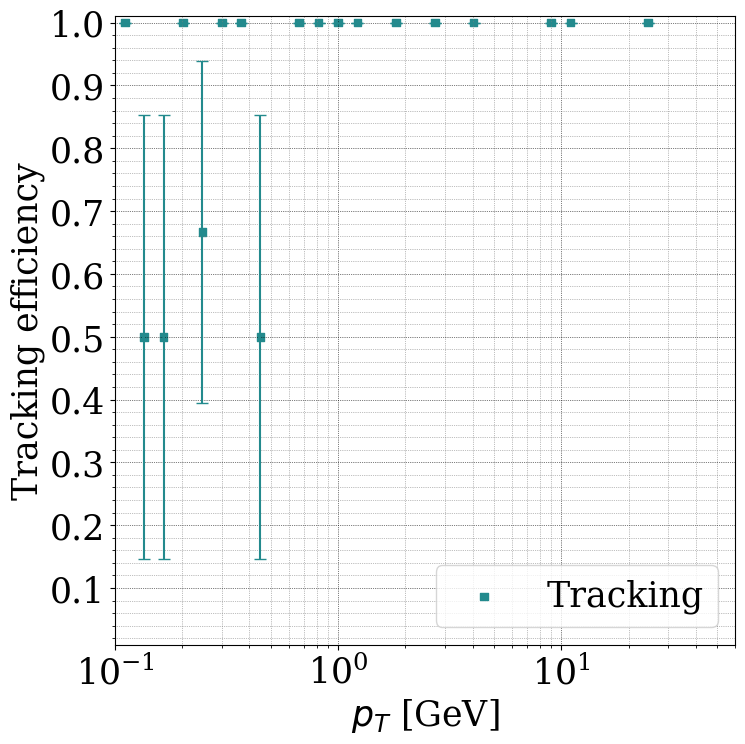

In [81]:
def get_clustering(betas: torch.Tensor, X: torch.Tensor, tbeta=0.7, td=0.7):
    """
    Returns a clustering of hits -> cluster_index, based on the GravNet model
    output (predicted betas and cluster space coordinates) and the clustering
    parameters tbeta and td.
    Takes torch.Tensors as input.
    """
    n_points = betas.size(0)
    select_condpoints = betas > tbeta
    # Get indices passing the threshold
    indices_condpoints = select_condpoints.nonzero()
    # Order them by decreasing beta value
    indices_condpoints = indices_condpoints[(-betas[select_condpoints]).argsort()]
    # Assign points to condensation points
    # Only assign previously unassigned points (no overwriting)
    # Points unassigned at the end are bkg (-1)
    unassigned = torch.arange(n_points).to(betas.device)
    clustering = -1 * torch.ones(n_points, dtype=torch.long).to(betas.device)
    while len(indices_condpoints) > 0 and len(unassigned) > 0:
        index_condpoint = indices_condpoints[0]
        d = torch.norm(X[unassigned] - X[index_condpoint][0], dim=-1)
        assigned_to_this_condpoint = unassigned[d < td]
        clustering[assigned_to_this_condpoint] = index_condpoint[0]
        unassigned = unassigned[~(d < td)]
        
        # calculate indices_codpoints again
        indices_condpoints = find_condpoints(betas, unassigned, tbeta)
    return clustering


def find_condpoints(betas, unassigned, tbeta):
    n_points = betas.size(0)
    select_condpoints = betas > tbeta
    device = betas.device
    mask_unassigned = torch.zeros(n_points).to(device)
    mask_unassigned[unassigned] = True
    select_condpoints = mask_unassigned.to(bool) * select_condpoints
    # Get indices passing the threshold
    indices_condpoints = select_condpoints.nonzero()
    # Order them by decreasing beta value
    indices_condpoints = indices_condpoints[(-betas[select_condpoints]).argsort()]
    return indices_condpoints

df_path = "/home/cern/cern406903/GGTF_trackFinder_training/model_training/graph_dataframe.pt"
data = torch.load(df_path, map_location="cpu")
df = pd.DataFrame(data)

df_path_part = "/home/cern/cern406903/GGTF_trackFinder_training/model_training/particle_info.pt"

data_part = torch.load(df_path_part, map_location="cpu")
data_part['eventNumber'] = data_part['batch_id'] + 1

df_event=df[df["eventNumber"]==1]
df_part_event = data_part[data_part["batch_id"]==0]

# Extract model outputs all at once (efficient)
model_output = torch.tensor(df_event["model_output"].tolist())
df_event["coords_x"] = model_output[:, 0].numpy()
df_event["coords_y"] = model_output[:, 1].numpy()
df_event["coords_z"] = model_output[:, 2].numpy()
df_event["beta"]     = torch.sigmoid(model_output[:, 3]).numpy()  # apply sigmoid here, once


df_event = df_event.drop(columns="model_output")

coords_tensor = torch.tensor(
    df_event[["coords_x", "coords_y", "coords_z"]].values,
    dtype=torch.float32
)
clustering = get_clustering(torch.sigmoid(model_output[:, 3]),coords_tensor,0.5,0.25)

df_event["clustering_id"] = clustering

merged_df = df_event.merge(df_part_event, on=["part_id"],how='left')
merged_df = merged_df.drop(columns=["eventNumber_x","eventNumber_y", "part_parent", "fileNumber", "batch_id"])

import numpy as np

# --- User-defined parameters ---
THETA_MIN_DEG = 10    # minimum |theta| in degrees
THETA_MAX_DEG = 170    # maximum |theta| in degrees
MIN_HITS      = 10    # minimum hits per particle

# Convert theta range to radians (matching the df's unit)
theta_min_rad = np.deg2rad(THETA_MIN_DEG)
theta_max_rad = np.deg2rad(THETA_MAX_DEG)


# --- Filter 3: remove particles with fewer than MIN_HITS hits ---
hit_counts    = merged_df.groupby("part_id")["part_id"].transform("count")
invalid_nhits = hit_counts > MIN_HITS

filter1 = merged_df[invalid_nhits]


invalid_theta = filter1.groupby("part_id")["part_theta"].transform(
    lambda s: s.abs().between(theta_min_rad, theta_max_rad).all()
)

filter2 = filter1[invalid_theta]

# --- Filter 1: remove particles with gen_status in [0, 1] ---
# A particle is invalid if ANY of its hits has gen_status in {0, 1}
valid_gen = filter2.groupby("part_id")["gen_status"].transform(
    lambda s: s.isin([0, 1]).any()
)

filtered_df = filter2[valid_gen]


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ══════════════════════════════════════════════════════════════════════════════
# 3. CLUSTER MATCHING  (purity + hit efficiency)
# ══════════════════════════════════════════════════════════════════════════════
PURITY_THR     = 0.5
EFFICIENCY_THR = 0.5

# total hits per true particle
hits_per_particle = (
    filtered_df
    .groupby('part_id')
    .size()
    .rename('total_particle_hits')
)

# shared hits between every (cluster, particle) pair
cluster_particle_hits = (
    filtered_df[filtered_df['clustering_id'].notna()]
    .groupby(['clustering_id', 'part_id'])
    .size()
    .reset_index(name='shared_hits')
)

# majority particle per cluster = particle contributing most hits
majority = (
    cluster_particle_hits
    .sort_values('shared_hits', ascending=False)
    .groupby('clustering_id')
    .first()
    .reset_index()
)

# total hits per cluster
hits_per_cluster = (
    filtered_df[filtered_df['clustering_id'].notna()]
    .groupby('clustering_id')
    .size()
    .rename('total_cluster_hits')
)

majority = majority.join(hits_per_cluster,  on='clustering_id')
majority = majority.join(hits_per_particle, on='part_id')

majority['purity']     = majority['shared_hits'] / majority['total_cluster_hits']
majority['hit_eff']    = majority['shared_hits'] / majority['total_particle_hits']
majority['is_matched'] = (
    (majority['purity']  >= PURITY_THR) &
    (majority['hit_eff'] >= EFFICIENCY_THR)
)

matched_part_ids = set(majority[majority['is_matched']]['part_id'])

# ══════════════════════════════════════════════════════════════════════════════
# 4. PER-PARTICLE TABLE
# ══════════════════════════════════════════════════════════════════════════════
particle_df = (
    filtered_df
    .groupby('part_id')
    .agg(pt=('part_p_t', 'first'))
    .reset_index()
)
particle_df['is_reco'] = particle_df['part_id'].isin(matched_part_ids)

# ══════════════════════════════════════════════════════════════════════════════
# 5. EFFICIENCY CALCULATION
# ══════════════════════════════════════════════════════════════════════════════
def limit_error_bars(efficiencies, errors, upper_limit=1.0, lower_limit=0.0):
    yerr_upper = np.where(efficiencies + errors > upper_limit,
                          upper_limit - efficiencies, errors)
    yerr_lower = np.where(efficiencies - errors < lower_limit,
                          efficiencies - lower_limit, errors)
    return yerr_lower, yerr_upper

minX, maxX  = 0.1, 60
bins        = np.exp(np.arange(np.log(minX), np.log(maxX), 0.2))
bin_indices = np.digitize(particle_df['pt'], bins)

efficiencies, errors, bin_centers = [], [], []

for i in range(1, len(bins)):
    df_bin  = particle_df[bin_indices == i]
    n_total = len(df_bin)
    bin_centers.append(np.sqrt(bins[i-1] * bins[i]))   # geometric centre
    if n_total == 0:
        efficiencies.append(np.nan)
        errors.append(0)
        continue
    n_matched = df_bin['is_reco'].sum()
    eff       = n_matched / n_total
    efficiencies.append(eff)
    errors.append(np.sqrt(eff * (1 - eff) / n_total))

bin_centers  = np.array(bin_centers)
efficiencies = np.array(efficiencies)
errors       = np.array(errors)

# ══════════════════════════════════════════════════════════════════════════════
# 6. PLOT
# ══════════════════════════════════════════════════════════════════════════════
plt.rcParams["text.usetex"]     = False
plt.rcParams["font.family"]     = "serif"
plt.rcParams['font.size']       = 25
plt.rcParams['axes.labelsize']  = 25
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 25

COLOR  = "#238A8DFF"
MARKER = "s"
LABEL  = "Tracking"

fig = plt.figure(figsize=(8, 8))
ax  = fig.add_subplot(111)

plt.scatter(bin_centers, efficiencies,
            label=LABEL, marker=MARKER,
            c=[COLOR] * len(bin_centers), s=30)

yerr_lower, yerr_upper = limit_error_bars(efficiencies, errors, upper_limit=1)
plt.errorbar(bin_centers, efficiencies,
             yerr=[yerr_lower, yerr_upper],
             ecolor=COLOR, linestyle='none', capsize=4)

plt.xlabel("$p_T$ [GeV]")
plt.ylabel("Tracking efficiency")
plt.xscale("log")
plt.xlim([minX, maxX])
plt.ylim([0.01, 1.01])
plt.legend(loc="lower right")

ax.xaxis.set_major_locator(plt.LogLocator(base=10.0, numticks=4))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs='auto', numticks=10))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.1))
plt.minorticks_on()
ax.grid(which='major', linestyle=':', linewidth=0.5, color='black')
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')

plt.tight_layout()
plt.show()

Found 100 events: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


Processing events: 100%|██████████| 100/100 [00:04<00:00, 22.68it/s]



Total reconstructable particles across all events: 2476
  of which reconstructed: 560

Per-event summary saved to per_event_efficiency.csv
              n_reconstructable  n_reconstructed  efficiency
event_number                                                
1                            38               11    0.289474
2                            29                6    0.206897
3                            25                5    0.200000
4                            18                4    0.222222
5                            17                5    0.294118
6                            12                3    0.250000
7                            20                2    0.100000
8                            15                2    0.133333
9                            38                7    0.184211
10                           20                5    0.250000
11                           30                4    0.133333
12                           17                5    0.294118
13    

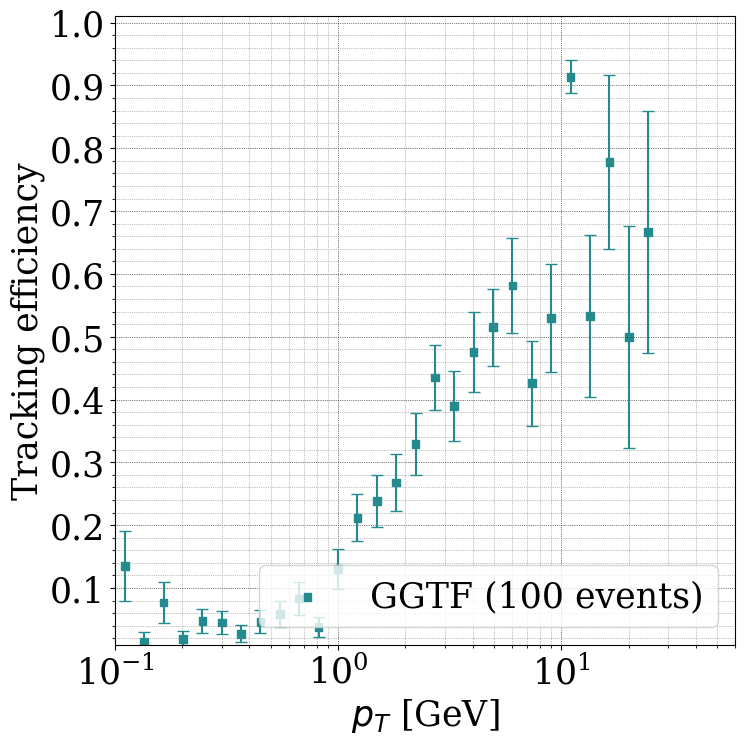

In [19]:
"""
Tracking efficiency pipeline  –  cumulative over all events
─────────────────────────────────────────────────────────────
Order of operations
  1. Load data
  2. For every event: cluster → match → filter → collect particle rows
  3. Compute cumulative tracking efficiency vs pT across all events
  4. Plot
"""

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# ══════════════════════════════════════════════════════════════════════════════
# 0. HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def find_condpoints(betas: torch.Tensor,
                    unassigned: torch.Tensor,
                    tbeta: float) -> torch.Tensor:
    n_points = betas.size(0)
    mask = torch.zeros(n_points, dtype=torch.bool, device=betas.device)
    mask[unassigned] = True
    select = mask & (betas > tbeta)
    indices = select.nonzero()
    return indices[(-betas[select]).argsort()]


def get_clustering(betas: torch.Tensor,
                   X: torch.Tensor,
                   tbeta: float = 0.7,
                   td: float = 0.7) -> torch.Tensor:
    n_points   = betas.size(0)
    unassigned = torch.arange(n_points, device=betas.device)
    clustering = torch.full((n_points,), -1, dtype=torch.long, device=betas.device)
    indices_condpoints = find_condpoints(betas, unassigned, tbeta)
    while len(indices_condpoints) > 0 and len(unassigned) > 0:
        idx_cp = indices_condpoints[0]
        d      = torch.norm(X[unassigned] - X[idx_cp[0]], dim=-1)
        mask   = d < td
        clustering[unassigned[mask]] = idx_cp[0]
        unassigned = unassigned[~mask]
        indices_condpoints = find_condpoints(betas, unassigned, tbeta)
    return clustering


def limit_error_bars(eff, err, upper=1.0, lower=0.0):
    up = np.where(eff + err > upper, upper - eff, err)
    lo = np.where(eff - err < lower, eff - lower, err)
    return lo, up


def process_event(df_event: pd.DataFrame,
                  df_part_event: pd.DataFrame,
                  tbeta: float = 0.5,
                  td: float = 0.25,
                  purity_thr: float = 0.5,
                  efficiency_thr: float = 0.5,
                  theta_min_deg: float = 10,
                  theta_max_deg: float = 170,
                  min_hits: int = 10) -> pd.DataFrame:
    """
    Process a single event end-to-end.

    Returns a DataFrame with columns [part_id, pt, is_reco] for every
    reconstructable particle in the event.
    """
    # ── 1. Extract model outputs ──────────────────────────────────────────────
    model_output = torch.tensor(df_event["model_output"].tolist())
    df_event = df_event.copy()
    df_event["coords_x"] = model_output[:, 0].numpy()
    df_event["coords_y"] = model_output[:, 1].numpy()
    df_event["coords_z"] = model_output[:, 2].numpy()
    df_event["beta"]     = torch.sigmoid(model_output[:, 3]).numpy()
    df_event = df_event.drop(columns="model_output")

    # ── 2. Clustering ─────────────────────────────────────────────────────────
    coords_tensor = torch.tensor(
        df_event[["coords_x", "coords_y", "coords_z"]].values,
        dtype=torch.float32
    )
    clustering = get_clustering(torch.sigmoid(model_output[:, 3]),
                                coords_tensor, tbeta, td)
    df_event["clustering_id"] = clustering.numpy()

    # ── 3. Merge with particle info ───────────────────────────────────────────
    merged_df = df_event.merge(df_part_event, on="part_id", how="left")
    drop_cols = [c for c in ["eventNumber_x", "eventNumber_y",
                              "part_parent", "fileNumber", "batch_id"]
                 if c in merged_df.columns]
    merged_df = merged_df.drop(columns=drop_cols)

    # ── 4. Cluster matching (purity + hit-efficiency) ─────────────────────────
    hits_per_particle = (
        merged_df.groupby("part_id").size().rename("total_particle_hits")
    )
    cluster_particle_hits = (
        merged_df[merged_df["clustering_id"] != -1]
        .groupby(["clustering_id", "part_id"])
        .size()
        .reset_index(name="shared_hits")
    )
    majority = (
        cluster_particle_hits
        .sort_values("shared_hits", ascending=False)
        .groupby("clustering_id").first()
        .reset_index()
    )
    hits_per_cluster = (
        merged_df[merged_df["clustering_id"] != -1]
        .groupby("clustering_id").size()
        .rename("total_cluster_hits")
    )
    majority = majority.join(hits_per_cluster,  on="clustering_id")
    majority = majority.join(hits_per_particle, on="part_id")
    majority["purity"]     = majority["shared_hits"] / majority["total_cluster_hits"]
    majority["hit_eff"]    = majority["shared_hits"] / majority["total_particle_hits"]
    majority["is_matched"] = (
        (majority["purity"]  >= purity_thr) &
        (majority["hit_eff"] >= efficiency_thr)
    )
    matched_part_ids = set(majority[majority["is_matched"]]["part_id"])

    # ── 5. Reconstructability filters ─────────────────────────────────────────
    theta_min_rad = np.deg2rad(theta_min_deg)
    theta_max_rad = np.deg2rad(theta_max_deg)

    hit_counts = merged_df.groupby("part_id")["part_id"].transform("count")
    f_nhits    = merged_df[hit_counts > min_hits]

    in_theta = f_nhits.groupby("part_id")["part_theta"].transform(
        lambda s: s.abs().between(theta_min_rad, theta_max_rad).all()
    )
    f_theta = f_nhits[in_theta]

    valid_gen = f_theta.groupby("part_id")["gen_status"].transform(
        lambda s: s.isin([0, 1]).any()
    )
    filtered_df = f_theta[valid_gen]

    # ── 6. Per-particle result table ──────────────────────────────────────────
    particle_df = (
        filtered_df
        .groupby("part_id")
        .agg(pt=("part_p_t", "first"))
        .reset_index()
    )
    particle_df["is_reco"] = particle_df["part_id"].isin(matched_part_ids)

    return particle_df


# ══════════════════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════

df_path = "/home/cern/cern406903/GGTF_trackFinder_training/model_training/graph_dataframe.pt"
data    = torch.load(df_path, map_location="cpu")
df      = pd.DataFrame(data)

df_path_part = "/home/cern/cern406903/GGTF_trackFinder_training/model_training/particle_info.pt"
data_part    = torch.load(df_path_part, map_location="cpu")
data_part["eventNumber"] = data_part["batch_id"] + 1

all_event_numbers = sorted(df["eventNumber"].unique())
print(f"Found {len(all_event_numbers)} events: {all_event_numbers}")

# ══════════════════════════════════════════════════════════════════════════════
# 2. LOOP OVER EVENTS  –  collect per-particle rows
# ══════════════════════════════════════════════════════════════════════════════

all_particles = []   # list of DataFrames, one per event

for event_num in tqdm(all_event_numbers, desc="Processing events"):
    batch_id = event_num - 1

    df_event      = df[df["eventNumber"] == event_num].copy()
    df_part_event = data_part[data_part["batch_id"] == batch_id].copy()

    if df_event.empty or df_part_event.empty:
        print(f"  [!] Event {event_num}: empty slice, skipping.")
        continue

    try:
        particle_df = process_event(df_event, df_part_event)
        particle_df["event_number"] = event_num   # keep provenance
        all_particles.append(particle_df)
    except Exception as exc:
        print(f"  [!] Event {event_num} failed: {exc}")

# Concatenate everything
all_particles_df = pd.concat(all_particles, ignore_index=True)
print(f"\nTotal reconstructable particles across all events: {len(all_particles_df)}")
print(f"  of which reconstructed: {all_particles_df['is_reco'].sum()}")

# ── Optional: save per-event summary ──────────────────────────────────────────
per_event_summary = (
    all_particles_df
    .groupby("event_number")
    .agg(
        n_reconstructable=("part_id", "count"),
        n_reconstructed  =("is_reco",  "sum"),
    )
    .assign(efficiency=lambda x: x["n_reconstructed"] / x["n_reconstructable"])
)
per_event_summary.to_csv("per_event_efficiency.csv")
print("\nPer-event summary saved to per_event_efficiency.csv")
print(per_event_summary.to_string())

# ══════════════════════════════════════════════════════════════════════════════
# 3. CUMULATIVE EFFICIENCY vs pT
# ══════════════════════════════════════════════════════════════════════════════

minX, maxX  = 0.1, 60
bins        = np.exp(np.arange(np.log(minX), np.log(maxX), 0.2))
bin_indices = np.digitize(all_particles_df["pt"], bins)

efficiencies, errors, bin_centers = [], [], []

for i in range(1, len(bins)):
    df_bin   = all_particles_df[bin_indices == i]
    n_total  = len(df_bin)
    bin_centers.append(np.sqrt(bins[i - 1] * bins[i]))
    if n_total == 0:
        efficiencies.append(np.nan)
        errors.append(0.0)
        continue
    n_matched = df_bin["is_reco"].sum()
    eff       = n_matched / n_total
    efficiencies.append(eff)
    errors.append(np.sqrt(eff * (1 - eff) / n_total))   # binomial uncertainty

bin_centers  = np.array(bin_centers)
efficiencies = np.array(efficiencies)
errors       = np.array(errors)

# ══════════════════════════════════════════════════════════════════════════════
# 4. PLOT
# ══════════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    "text.usetex":     False,
    "font.family":     "serif",
    "font.size":       25,
    "axes.labelsize":  25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "legend.fontsize": 25,
})

COLOR  = "#238A8DFF"
MARKER = "s"

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(bin_centers, efficiencies,
           label=f"GGTF ({len(all_event_numbers)} events)",
           marker=MARKER, c=[COLOR] * len(bin_centers), s=30)

yerr_lo, yerr_up = limit_error_bars(efficiencies, errors)
ax.errorbar(bin_centers, efficiencies,
            yerr=[yerr_lo, yerr_up],
            ecolor=COLOR, linestyle="none", capsize=4)

ax.set_xlabel("$p_T$ [GeV]")
ax.set_ylabel("Tracking efficiency")
ax.set_xscale("log")
ax.set_xlim([minX, maxX])
ax.set_ylim([0.01, 1.01])
ax.legend(loc="lower right")

ax.xaxis.set_major_locator(plt.LogLocator(base=10.0, numticks=4))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs="auto", numticks=10))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

plt.minorticks_on()
ax.grid(which="major", linestyle=":", linewidth=0.5, color="black")
ax.grid(which="minor", linestyle=":", linewidth=0.5, color="gray")

plt.tight_layout()
plt.savefig("tracking_efficiency_cumulative.pdf", bbox_inches="tight")
plt.show()

/scratch/tmp/ipykernel_1762551/4066031818.py:99: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_event["coords_x"] = model_output[:, 0].numpy()
/scratch/tmp/ipykernel_1762551/4066031818.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_event["coords_y"] = model_output[:, 1].numpy()
/scratch/tmp/ipykernel_1762551/4066031818.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

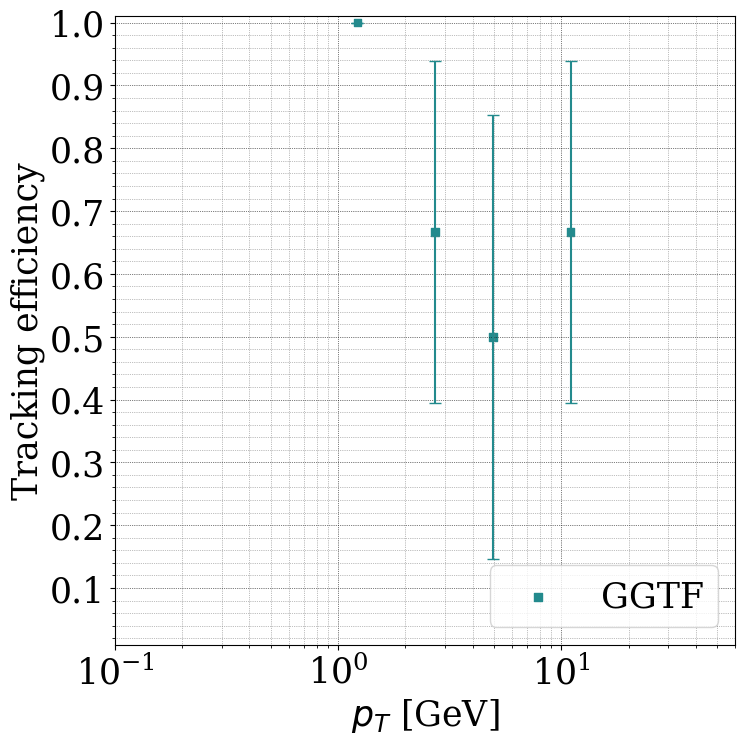

In [20]:
"""
Tracking efficiency pipeline
─────────────────────────────
Order of operations
  1. Load data & run clustering
  2. Compute cluster-level purity and hit-efficiency  (on *all* hits)
  3. Apply reconstructability filters                 (theta, n_hits, gen_status)
  4. Compute per-particle tracking efficiency vs pT
  5. Plot
"""

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

num_test = 2
num_test_batch = num_test - 1

# ══════════════════════════════════════════════════════════════════════════════
# 0. HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def find_condpoints(betas: torch.Tensor,
                    unassigned: torch.Tensor,
                    tbeta: float) -> torch.Tensor:
    """Return condensation-point indices among *unassigned* hits, sorted by
    decreasing beta."""
    n_points = betas.size(0)
    mask = torch.zeros(n_points, dtype=torch.bool, device=betas.device)
    mask[unassigned] = True
    select = mask & (betas > tbeta)
    indices = select.nonzero()
    return indices[(-betas[select]).argsort()]


def get_clustering(betas: torch.Tensor,
                   X: torch.Tensor,
                   tbeta: float = 0.7,
                   td: float = 0.7) -> torch.Tensor:
    """Object condensation clustering.

    Parameters
    ----------
    betas  : (N,) predicted beta values (after sigmoid)
    X      : (N, D) cluster-space coordinates
    tbeta  : condensation-point threshold
    td     : distance threshold for assignment

    Returns
    -------
    clustering : (N,) long tensor; -1 = background / unassigned
    """
    n_points  = betas.size(0)
    unassigned = torch.arange(n_points, device=betas.device)
    clustering = torch.full((n_points,), -1, dtype=torch.long, device=betas.device)

    indices_condpoints = find_condpoints(betas, unassigned, tbeta)

    while len(indices_condpoints) > 0 and len(unassigned) > 0:
        idx_cp = indices_condpoints[0]                               # shape (1,)
        d      = torch.norm(X[unassigned] - X[idx_cp[0]], dim=-1)
        mask   = d < td
        clustering[unassigned[mask]] = idx_cp[0]
        unassigned = unassigned[~mask]
        indices_condpoints = find_condpoints(betas, unassigned, tbeta)

    return clustering


def limit_error_bars(eff: np.ndarray,
                     err: np.ndarray,
                     upper: float = 1.0,
                     lower: float = 0.0):
    """Clip error bars so they don't exceed [lower, upper]."""
    up = np.where(eff + err > upper, upper - eff, err)
    lo = np.where(eff - err < lower, eff - lower, err)
    return lo, up


# ══════════════════════════════════════════════════════════════════════════════
# 1. LOAD DATA & RUN CLUSTERING
# ══════════════════════════════════════════════════════════════════════════════

df_path = "/home/cern/cern406903/GGTF_trackFinder_training/model_training/graph_dataframe.pt"
data = torch.load(df_path, map_location="cpu")
df = pd.DataFrame(data)

df_path_part = "/home/cern/cern406903/GGTF_trackFinder_training/model_training/particle_info.pt"

data_part = torch.load(df_path_part, map_location="cpu")
data_part['eventNumber'] = data_part['batch_id'] + 1

df_event=df[df["eventNumber"]==num_test]
df_part_event = data_part[data_part["batch_id"]==num_test_batch]

# Extract model outputs all at once (efficient)
model_output = torch.tensor(df_event["model_output"].tolist())
df_event["coords_x"] = model_output[:, 0].numpy()
df_event["coords_y"] = model_output[:, 1].numpy()
df_event["coords_z"] = model_output[:, 2].numpy()
df_event["beta"]     = torch.sigmoid(model_output[:, 3]).numpy()  # apply sigmoid here, once


df_event = df_event.drop(columns="model_output")

coords_tensor = torch.tensor(
    df_event[["coords_x", "coords_y", "coords_z"]].values,
    dtype=torch.float32
)
clustering = get_clustering(torch.sigmoid(model_output[:, 3]),coords_tensor,0.5,0.25)

df_event["clustering_id"] = clustering

merged_df = df_event.merge(df_part_event, on=["part_id"],how='left')
merged_df = merged_df.drop(columns=["eventNumber_x","eventNumber_y", "part_parent", "fileNumber", "batch_id"])


# ══════════════════════════════════════════════════════════════════════════════
# 2. CLUSTER MATCHING  –  purity & hit efficiency 
# ══════════════════════════════════════════════════════════════════════════════

PURITY_THR     = 0.5
EFFICIENCY_THR = 0.5

# Total true hits per particle
hits_per_particle = (
    merged_df
    .groupby("part_id")
    .size()
    .rename("total_particle_hits")
)

# Shared hits between every (cluster, particle) pair
cluster_particle_hits = (
    merged_df[merged_df["clustering_id"] != -1]
    .groupby(["clustering_id", "part_id"])
    .size()
    .reset_index(name="shared_hits")
)

# Majority particle per cluster  (particle contributing the most hits)
majority = (
    cluster_particle_hits
    .sort_values("shared_hits", ascending=False)
    .groupby("clustering_id")
    .first()
    .reset_index()
)

# Total hits per cluster
hits_per_cluster = (
    merged_df[merged_df["clustering_id"] != -1]
    .groupby("clustering_id")
    .size()
    .rename("total_cluster_hits")
)

majority = majority.join(hits_per_cluster,  on="clustering_id")
majority = majority.join(hits_per_particle, on="part_id")

majority["purity"]     = majority["shared_hits"] / majority["total_cluster_hits"]
majority["hit_eff"]    = majority["shared_hits"] / majority["total_particle_hits"]
majority["is_matched"] = (
    (majority["purity"]  >= PURITY_THR) &
    (majority["hit_eff"] >= EFFICIENCY_THR)
)

# Set of reconstructed particle IDs (globally, before any filter)
matched_part_ids = set(majority[majority["is_matched"]]["part_id"])


# ══════════════════════════════════════════════════════════════════════════════
# 3. RECONSTRUCTABILITY FILTERS
# ══════════════════════════════════════════════════════════════════════════════

THETA_MIN_DEG = 10
THETA_MAX_DEG = 170
MIN_HITS      = 10

theta_min_rad = np.deg2rad(THETA_MIN_DEG)
theta_max_rad = np.deg2rad(THETA_MAX_DEG)

# Filter A: minimum number of hits per particle
hit_counts   = merged_df.groupby("part_id")["part_id"].transform("count")
f_nhits      = merged_df[hit_counts > MIN_HITS]

# Filter B: all hits of the particle must fall within the theta acceptance
in_theta = f_nhits.groupby("part_id")["part_theta"].transform(
    lambda s: s.abs().between(theta_min_rad, theta_max_rad).all()
)
f_theta = f_nhits[in_theta]

# Filter C: at least one hit must carry gen_status in {0, 1}
valid_gen = f_theta.groupby("part_id")["gen_status"].transform(
    lambda s: s.isin([0, 1]).any()
)
filtered_df = f_theta[valid_gen]


# ══════════════════════════════════════════════════════════════════════════════
# 4. PER-PARTICLE TABLE  –  is the reconstructable particle reconstructed?
# ══════════════════════════════════════════════════════════════════════════════

particle_df = (
    filtered_df
    .groupby("part_id")
    .agg(pt=("part_p_t", "first"))
    .reset_index()
)
particle_df["is_reco"] = particle_df["part_id"].isin(matched_part_ids)


# ══════════════════════════════════════════════════════════════════════════════
# 5. EFFICIENCY vs pT
# ══════════════════════════════════════════════════════════════════════════════

minX, maxX  = 0.1, 60
bins        = np.exp(np.arange(np.log(minX), np.log(maxX), 0.2))
bin_indices = np.digitize(particle_df["pt"], bins)

efficiencies, errors, bin_centers = [], [], []

for i in range(1, len(bins)):
    df_bin  = particle_df[bin_indices == i]
    n_total = len(df_bin)
    bin_centers.append(np.sqrt(bins[i - 1] * bins[i]))   # geometric centre
    if n_total == 0:
        efficiencies.append(np.nan)
        errors.append(0.0)
        continue
    n_matched = df_bin["is_reco"].sum()
    eff       = n_matched / n_total
    efficiencies.append(eff)
    errors.append(np.sqrt(eff * (1 - eff) / n_total))

bin_centers  = np.array(bin_centers)
efficiencies = np.array(efficiencies)
errors       = np.array(errors)


# ══════════════════════════════════════════════════════════════════════════════
# 6. PLOT
# ══════════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    "text.usetex":      False,
    "font.family":      "serif",
    "font.size":        25,
    "axes.labelsize":   25,
    "xtick.labelsize":  25,
    "ytick.labelsize":  25,
    "legend.fontsize":  25,
})

COLOR  = "#238A8DFF"
MARKER = "s"

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(bin_centers, efficiencies,
           label="GGTF", marker=MARKER,
           c=[COLOR] * len(bin_centers), s=30)

yerr_lo, yerr_up = limit_error_bars(efficiencies, errors, upper=1.0)
ax.errorbar(bin_centers, efficiencies,
            yerr=[yerr_lo, yerr_up],
            ecolor=COLOR, linestyle="none", capsize=4)

ax.set_xlabel("$p_T$ [GeV]")
ax.set_ylabel("Tracking efficiency")
ax.set_xscale("log")
ax.set_xlim([minX, maxX])
ax.set_ylim([0.01, 1.01])
ax.legend(loc="lower right")

ax.xaxis.set_major_locator(plt.LogLocator(base=10.0, numticks=4))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs="auto", numticks=10))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

plt.minorticks_on()
ax.grid(which="major", linestyle=":", linewidth=0.5, color="black")
ax.grid(which="minor", linestyle=":", linewidth=0.5, color="gray")

plt.tight_layout()
plt.savefig("tracking_efficiency.pdf", bbox_inches="tight")
plt.show()

# Tracking Efficiency

In [1]:
import gzip
import pickle 
# import mplhep as hep
# hep.style.use("CMS")
import matplotlib
matplotlib.rc('font', size=15)
import numpy as np
import torch 
import dgl
import pandas as pd
import numpy as np
import plotly.express as px
import sys
import os

notebook_dir = os.getcwd()
project_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
sys.path.append(os.path.join(project_dir,"model_training"))

print(project_dir)
from sklearn.cluster import DBSCAN
#from torch_scatter import scatter_max, scatter_add, scatter_mean
# from src.layers.inference_oc import get_clustering, obtain_intersection_values
from scipy.optimize import linear_sum_assignment
import numpy as np
import matplotlib.pyplot as plt

def limit_error_bars(y, yerr, upper_limit=1):
    yerr_upper = np.minimum(y + yerr, upper_limit) - y
    yerr_lower = yerr
    return yerr_lower, yerr_upper

Using backend: pytorch


/gpfs/home/cern/cern406903/GGTF_trackFinder_training


In [5]:
from src.utils.inference.pandas_helpers import open_tracking_dataframe
path_tracking = "/home/cern/cern406903/training_results/test/showers_df_evaluation/0_0_0IDEAtracking.pt"
# path_tracking=  "/home/cern/cern406903/training_results/test/showers_df_evaluation/05_007_IDEAtracking.pt"

path_tracking = "/home/cern/cern406903/training_results/modelWithNewLossBiggerClusteringSpace/showers_df_evaluation/0_0_0IDEAtracking.pt"

df_raw = open_tracking_dataframe(path_tracking)

def theta_to_float(x):
    if x is None:
        return None
    elif isinstance(x, (list, np.ndarray)):
        return float(x[0]) if len(x) > 0 else None
    else:
        return float(x)

df_raw["theta"] = df_raw["theta"].apply(theta_to_float)

In [11]:
df_raw[df_raw["eventGlob"]==1003]

,fileID,eventID,partIndex,pid,energy,pT,deltaMC,theta,genStatus,numSIhits,numCDChits,trackLabel,hitEfficiency,hitPurity,eventGlob
0,1002,1,0,11.0,10.149658,10.101246,0,1.473086,1.0,7,110,[],[],[],1003
1,1002,1,29,-211.0,8.273065,8.219721,0,1.458430,1.0,6,106,[58],[0.008928571428571428],[1.0],1003
2,1002,1,30,211.0,1.028602,0.889773,0,1.061539,1.0,7,142,[],[],[],1003
3,1002,1,52,-211.0,2.398394,2.127516,0,1.094206,1.0,6,38,[],[],[],1003
4,1002,1,54,211.0,9.936961,9.398973,0,1.240521,1.0,7,108,[],[],[],1003
5,1002,1,56,-211.0,2.955146,2.617429,0,1.090177,1.0,7,115,[],[],[],1003
6,1002,1,58,211.0,0.300119,0.264338,0,1.469825,1.0,7,509,"[51, 52, 53, 54, 55, 82, 83, 84, 85, 86, 87, 8...","[0.001937984496124031, 0.001937984496124031, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1003
7,1002,1,59,3112.0,2.401124,2.081199,0,1.565508,2.0,3,0,[49],[0.3333333333333333],[1.0],1003
8,1002,1,63,2212.0,23.935239,22.954432,0,1.855446,1.0,7,102,"[26, 27, 28, 29, 30, 73, 74, 285, 286, 287, 28...","[0.009174311926605505, 0.009174311926605505, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1003
9,1002,1,72,211.0,1.708374,1.662861,0,1.354150,1.0,7,133,[],[],[],1003


In [6]:
import numpy as np
import copy
import math

def max_track_label(x):
    if isinstance(x, list) and len(x) > 0:
        return max(x)
    elif isinstance(x, np.ndarray) and x.size > 0:
        return x.flatten().max()
    elif isinstance(x, (int, float)):
        return x
    else:
        return np.nan

df_raw["eventGlob"] = df_raw["fileID"] + df_raw["eventID"]  
event_ids = np.arange(df_raw["eventGlob"].min(), df_raw["eventGlob"].max() + 1)

df_raw = df_raw.reset_index(drop=True)

num_reco_tracks = 0
num_fake_tracks = 0
num_merged_tracks = 0
merged_indices = []  

df_raw_with_extraAssignation = df_raw.applymap(lambda x: copy.deepcopy(x))

df_raw_with_extraAssignation["isReco"] = (~df_raw_with_extraAssignation["pid"].isna()).astype(int)
df_raw_with_extraAssignation["isRecoMerged"] = 0
df_raw_with_extraAssignation["isFake"] = (df_raw_with_extraAssignation["pid"].isna()).astype(int)
df_raw_with_extraAssignation["isMerged"] = 0

for event in event_ids:
    
    df_event = df_raw_with_extraAssignation[df_raw_with_extraAssignation["eventGlob"] == event]
    
    max_label = df_event["trackLabel"].apply(max_track_label).max()
    if math.isnan(max_label):
        max_label = 0

    num_reco_tracks += max_label
    
    df_fake_tracks = df_event[df_event["isFake"] == 1]
    
    for row_idx, (eff_list, part_list) in df_fake_tracks[["hitEfficiency", "partIndex"]].iterrows():
    
        good_idx = [i for i, eff in enumerate(eff_list) if eff > 0.70]
        
        if len(good_idx) > 1 and df_fake_tracks.loc[row_idx, "trackLabel"] != 0:
            
            num_merged_tracks += 1

            track_label_arr = df_raw_with_extraAssignation.loc[row_idx, "trackLabel"]
            track_purity_arr = df_raw_with_extraAssignation.loc[row_idx, "hitPurity"]
            track_eff_arr    = df_raw_with_extraAssignation.loc[row_idx, "hitEfficiency"]
            
            df_raw_with_extraAssignation.at[row_idx, "isFake"] = 0
            df_raw_with_extraAssignation.at[row_idx, "isMerged"] = 1
            
            for i in good_idx:
                
                particle_id = part_list[i]
                row_particle = df_raw_with_extraAssignation.index[(df_raw_with_extraAssignation["eventGlob"] == event) & (df_raw_with_extraAssignation["partIndex"] == particle_id)]

                row_particle = row_particle[0]
                
                df_raw_with_extraAssignation.at[row_particle, "trackLabel"].append(track_label_arr)
                df_raw_with_extraAssignation.at[row_particle, "hitPurity"].append(track_purity_arr[i])
                df_raw_with_extraAssignation.at[row_particle, "hitEfficiency"].append(track_eff_arr[i])
                df_raw_with_extraAssignation.at[row_particle, "isRecoMerged"] = 1
                df_raw_with_extraAssignation.at[row_particle, "isReco"] = 0
                
        elif len(good_idx) <= 1 and df_fake_tracks.loc[row_idx, "trackLabel"] != 0:
            
            num_fake_tracks += 1
            
print(f"Fake Rate : {num_fake_tracks} / {num_reco_tracks} = {num_fake_tracks / num_reco_tracks:.4f}")
print(f"Merge Rate: {num_merged_tracks} / {num_reco_tracks} = {num_merged_tracks / num_reco_tracks:.4f}")

Fake Rate : 61 / 363064.0 = 0.0002
Merge Rate: 0 / 363064.0 = 0.0000


In [7]:
def efficiency_purity_plot(df, minX, maxX, binStep, applyConstraints = False, maxR = 0.05, minDeltaMC = 0.02, minNumHits = 3, minTheta = 10, maxTheta = 170, genStatus = [0,1]):
    
    bins = np.exp(np.arange(np.log(minX), np.log(maxX), binStep))
    
    df_valid = df.copy()
    df_valid = df_valid.dropna()
    mask = df_valid["trackLabel"].apply(lambda x: isinstance(x, list) and 0 in x)
    df_valid.loc[mask, "trackLabel"] = df_valid.loc[mask, "trackLabel"].apply(lambda _: [])
    
    
    df_valid = df_valid[df_valid["trackLabel"].apply(bool)]

    df_valid["theta_deg"] = np.degrees(df_valid["theta"])
    
    if applyConstraints: 
        df_valid = df_valid[(df_valid["theta_deg"] > minTheta) & (df_valid["theta_deg"] < maxTheta)]
        df_valid = df_valid[df_valid["genStatus"].isin(genStatus)]
        df_valid = df_valid[(df_valid["pT"] > 0)]
        df_valid = df_valid[(df_valid["numSIhits"] + df_valid["numCDChits"] > minNumHits)]
        # df_valid = df_valid[(df_valid["R"] < maxR)]
        # df_valid = df_valid[(df_valid["deltaMC"] > minDeltaMC)]
    else:
        df_valid = df_valid[(df_valid["theta_deg"] > minTheta) & (df_valid["theta_deg"] < maxTheta)]
        
    bin_indices = np.digitize(df_valid["pT"], bins)    
    
    efficiencies = []
    purities = []
    bin_centers = []
    errors_eff = []
    errors_pur = []

    for i in range(1, len(bins)):
        df_bin = df_valid[bin_indices == i]
        n_total = len(df_bin)

        bin_centers.append((bins[i-1] + bins[i]) / 2)

        if n_total == 0:
            efficiencies.append(np.nan)
            purities.append(np.nan)
            errors_eff.append(0)
            errors_pur.append(0)
            continue

        eff_arr_raw = df_bin["hitEfficiency"].to_list()
        pur_arr_raw = df_bin["hitPurity"].to_list()

        eff_arr = []
        pur_arr = []

        for idx, el in enumerate(eff_arr_raw):
            if not isinstance(el, (list, np.ndarray)):
                continue  

            max_eff_idx = 0
            max_eff = -np.inf  

            for sub_idx, sub_el in enumerate(el):
                if sub_el > max_eff:
                    max_eff = sub_el
                    max_eff_idx = sub_idx

            eff_arr.append(el[max_eff_idx])
            pur_arr.append(pur_arr_raw[idx][max_eff_idx])
            
        pur_arr = np.array(pur_arr, dtype=float)
        eff_arr = np.array(eff_arr, dtype=float)
        

        # Means
        eff = np.mean(eff_arr)
        pur = np.mean(pur_arr)

        efficiencies.append(eff)
        purities.append(pur)

        # Standard error on the mean
        errors_eff.append(np.std(eff_arr, ddof=1) / np.sqrt(n_total))
        errors_pur.append(np.std(pur_arr, ddof=1) / np.sqrt(n_total))

    bin_centers = np.array(bin_centers)
    efficiencies = np.array(efficiencies)
    purities = np.array(purities)
    errors_eff = np.array(errors_eff)
    errors_pur = np.array(errors_pur)

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111)

    colors = ["#238A8DFF", "#440154FF"]
    markers = ["s", "o"]
    labels = ["Hit efficiency", "Hit purity"]

    # Efficiency
    ax.scatter(bin_centers, efficiencies, marker=markers[0], label=labels[0], s=35)
    yerr_low, yerr_up = limit_error_bars(efficiencies, errors_eff, upper_limit=1)
    ax.errorbar(bin_centers, efficiencies, yerr=[yerr_low, yerr_up], linestyle='none', capsize=4)

    # Purity
    ax.scatter(bin_centers, purities, marker=markers[1], label=labels[1], s=35)
    yerr_low_p, yerr_up_p = limit_error_bars(purities, errors_pur, upper_limit=1)
    ax.errorbar(bin_centers, purities, yerr=[yerr_low_p, yerr_up_p], linestyle='none', capsize=4)

    ax.set_xscale("log")
    ax.set_xlim([minX, maxX])
    ax.set_ylim([0.01, 1.01])
    ax.set_xlabel("$p_T$ [GeV]")
    ax.set_ylabel("Hit efficiency / purity")
    ax.legend(loc="lower right")

    ax.xaxis.set_major_locator(plt.LogLocator(base=10.0, numticks=4))
    ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs='auto', numticks=10))
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.1))
    ax.grid(which='major', linestyle=':', linewidth=0.5, color='black')
    ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')

    if applyConstraints:
        textbox_text = (
            r"$Z/\gamma^* \rightarrow q\bar{q} (uds)$" "\n"
            r"$m_Z = 91~\mathrm{GeV}$" "\n"
            rf"${minTheta}^\circ < \theta < {maxTheta}^\circ$" "\n"
            rf"$N_\mathrm{{hits}} = N_\mathrm{{SI}} + N_\mathrm{{CDC}} > {minNumHits}$" "\n"
            # rf"$R < {maxR}$" "\n"
            # rf"$\Delta_\mathrm{{MC}} > {minDeltaMC}$" "\n"
            rf"$genStatus \in {genStatus}$"
        )
        
        ax.text(
            0.55, 0.5, textbox_text,
            transform=ax.transAxes,
            fontsize=22,
            verticalalignment='center',
            horizontalalignment='left',
            linespacing=1.4,
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="none",
                edgecolor="none"
                )
        )
        
    else:
        textbox_text = (
            r"$Z/\gamma^* \rightarrow f\bar{f}$" "\n"
            r"$m_Z = 91~\mathrm{GeV}$" "\n"
            rf"${minTheta}^\circ < \theta < {maxTheta}^\circ$"
        )
        
        ax.text(
            0.62, 0.33, textbox_text,
            transform=ax.transAxes,
            fontsize=22,
            verticalalignment='center',
            horizontalalignment='left',
            linespacing=1.4,
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="none",
                edgecolor="none"
                )
        )
    
   

    plt.show()    

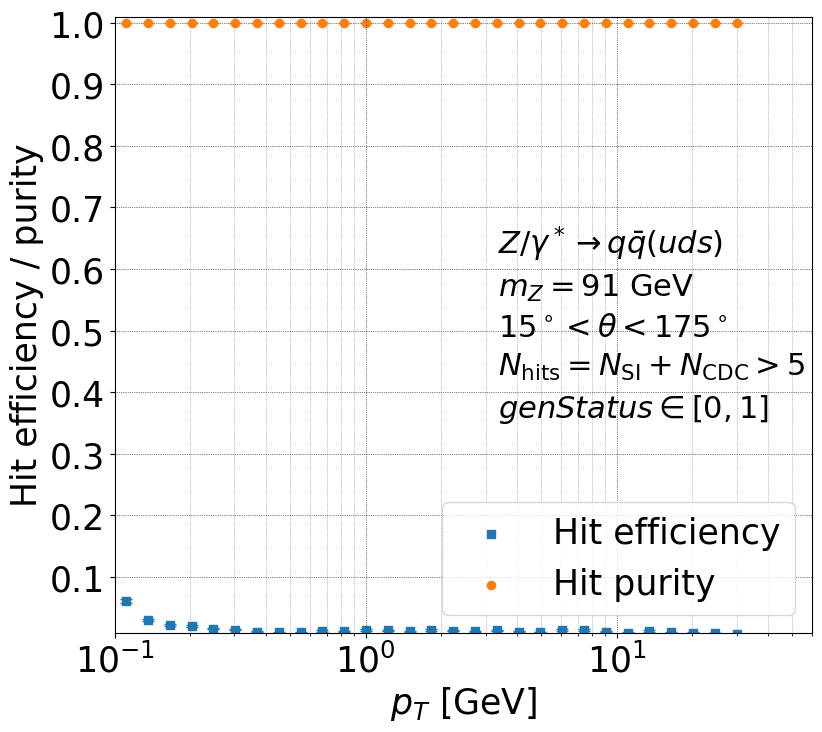

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = False

efficiency_purity_plot(df_raw,0.1,60,0.2,True, genStatus=[0,1], minNumHits=5, minTheta = 15, maxTheta = 175)

In [9]:
def trackingEfficiencyPlot(df, minX, maxX, binStep, applyConstraints = False, maxR = 0.05, minDeltaMC = 0.02, minNumHits = 3, minTheta = 10, maxTheta = 170, genStatus = [0,1]):
    
    bins = np.exp(np.arange(np.log(minX), np.log(maxX), binStep))
    
    df_valid = df.copy()
    df_valid = df_valid.dropna()
    
    mask = df_valid["trackLabel"].apply(lambda x: isinstance(x, list) and 0 in x)
    df_valid.loc[mask, "trackLabel"] = df_valid.loc[mask, "trackLabel"].apply(lambda _: [])
    
    df_valid["theta_deg"] = np.degrees(df_valid["theta"])
    
    if applyConstraints: 
        df_valid = df_valid[(df_valid["theta_deg"] > minTheta) & (df_valid["theta_deg"] < maxTheta)]
        df_valid = df_valid[df_valid["genStatus"].isin(genStatus)]
        df_valid = df_valid[(df_valid["pT"] > 0)]
        df_valid = df_valid[(df_valid["numSIhits"] + df_valid["numCDChits"] > minNumHits)]
        # df_valid = df_valid[(df_valid["R"] < maxR)]
        # df_valid = df_valid[(df_valid["deltaMC"] > minDeltaMC)]
    else:
        df_valid = df_valid[(df_valid["theta_deg"] > minTheta) & (df_valid["theta_deg"] < maxTheta)]
          
    bin_indices = np.digitize(df_valid["pT"], bins)    
    
    efficiencies = []
    bin_centers = []
    errors = []

    for i in range(1, len(bins)):
        df_bin = df_valid[bin_indices == i]
        n_total = len(df_bin)
        if n_total == 0:
            efficiencies.append(np.nan)
            errors.append(0)
            bin_centers.append((bins[i-1] + bins[i])/2)
            continue
        
        n_matched = df_bin["trackLabel"].apply(lambda x: isinstance(x, list) and len(x) > 0).sum()
    
        eff = n_matched / n_total
        efficiencies.append(eff)
        
        # Binomial error
        err = np.sqrt(eff * (1-eff) / n_total)
        errors.append(err)
        bin_centers.append((bins[i-1] + bins[i])/2)


    bin_centers = np.array(bin_centers)
    efficiencies = np.array(efficiencies)
    errors = np.array(errors)
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111)

    colors = ["#238A8DFF"]
    marker = ["s"]
    label = ["GGTF IDEA"]

    plt.scatter(
        bin_centers,
        efficiencies,
        label=label[0],
        marker=marker[0],
        c=[colors[0] for _ in range(len(bin_centers))],
        s=30
    )

    yerr_lower, yerr_upper = limit_error_bars(efficiencies, errors, upper_limit=1)
    plt.errorbar(bin_centers, efficiencies, yerr=[yerr_lower, yerr_upper], ecolor=colors[0], linestyle='none', capsize=4)

    plt.xlabel("$p_T$ [GeV]")
    plt.ylabel("Tracking efficiency")
    plt.xscale("log")
    plt.xlim([minX, maxX])
    plt.ylim([0.01, 1.01])
    plt.legend(loc="lower right")

    ax.xaxis.set_major_locator(plt.LogLocator(base=10.0, numticks=4))
    ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs='auto', numticks=10))
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.1))
    plt.minorticks_on()
    ax.grid(which='major', linestyle=':', linewidth=0.5, color='black')
    ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')

    plt.rcParams["text.usetex"] = False
    plt.rcParams["font.family"] = "serif"
    plt.rcParams['font.size'] = 25
    plt.rcParams['axes.labelsize'] = 25
    plt.rcParams['xtick.labelsize'] = 25
    plt.rcParams['ytick.labelsize'] = 25
    plt.rcParams['legend.fontsize'] = 25
    leg = ax.get_legend()
    leg._legend_box.align = "left"

    if applyConstraints:
        textbox_text = (
            r"$Z/\gamma^* \rightarrow q\bar{q}\ (q = u, d, s)$" "\n"
            r"$\sqrt{s} = m_Z = 91~\mathrm{GeV}$" "\n"
            rf"${minTheta}^\circ < \theta < {maxTheta}^\circ$" "\n"
            rf"$N_\mathrm{{hits}} = N_\mathrm{{SI}} + N_\mathrm{{CDC}} > {minNumHits}$" "\n"
            # rf"$R < {maxR}$" "\n"
            # rf"$\Delta_\mathrm{{MC}} > {minDeltaMC}$" "\n"
            rf"$genStatus \in {genStatus}$"
        )
        
        ax.text(
            0.45, 0.3, textbox_text,
            transform=ax.transAxes,
            fontsize=22,
            verticalalignment='center',
            horizontalalignment='left',
            linespacing=1.4,
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="none",
                edgecolor="none"
                )
        )
        
    else:
        textbox_text = (
            r"$Z/\gamma^* \rightarrow f\bar{f}$" "\n"
            r"$m_Z = 91~\mathrm{GeV}$" "\n"
            rf"${minTheta}^\circ < \theta < {maxTheta}^\circ$"
        )
        
        ax.text(
            0.62, 0.33, textbox_text,
            transform=ax.transAxes,
            fontsize=22,
            verticalalignment='center',
            horizontalalignment='left',
            linespacing=1.4,
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="none",
                edgecolor="none"
                )
        )

    plt.show()

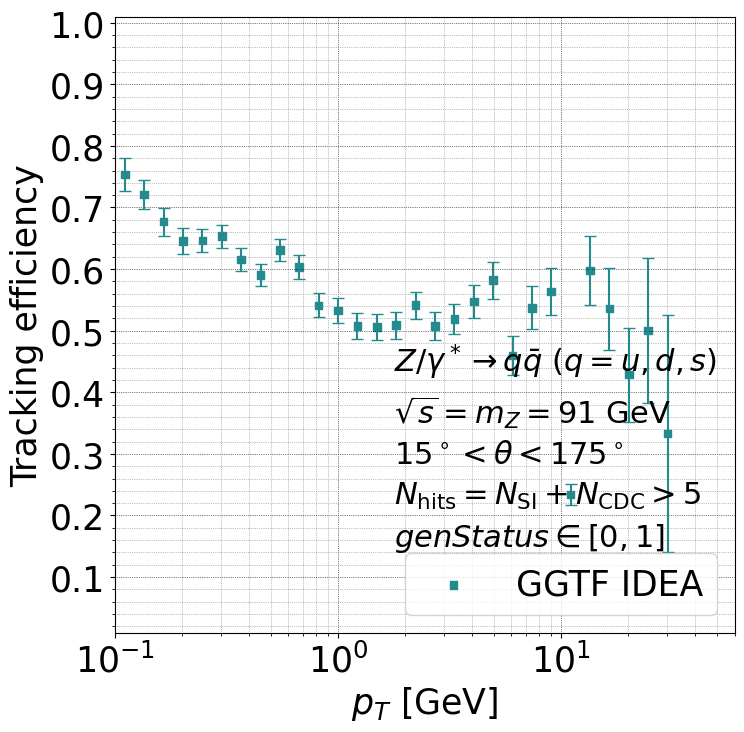

In [10]:
plt.rcParams['text.usetex'] = False

trackingEfficiencyPlot(df_raw,0.1,60,0.2,True, genStatus=[0,1], minNumHits=5, minTheta = 15, maxTheta = 175)

# Event Display

In [12]:
from src.utils.inference.pandas_helpers import open_tracking_dataframe

path_tracking = "/home/cern/cern406903/training_results/modelWithNewLossBiggerClusteringSpace/showers_df_evaluation/0_0_0IDEAtracking.pt"
df_raw = open_tracking_dataframe(path_tracking)

In [16]:
df_raw_event = df_raw[df_raw["eventID"]==2].copy()
df_raw_event

,fileID,eventID,partIndex,pid,energy,pT,deltaMC,theta,genStatus,numSIhits,numCDChits,trackLabel,hitEfficiency,hitPurity
0,1002,2,0,11.0,10.149658,10.101246,0,1.473086,1.0,7,106,"[61, 62, 63, 98]","[0.008849557522123894, 0.008849557522123894, 0...","[1.0, 1.0, 1.0, 1.0]"
1,1002,2,28,321.0,2.575594,2.517968,0,1.4824,1.0,7,120,"[39, 40, 41, 42, 43, 66, 67, 392, 393, 394, 39...","[0.007874015748031496, 0.007874015748031496, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
2,1002,2,29,-321.0,0.566645,0.086069,0,2.826994,1.0,10,0,"[5, 6, 7, 37, 38]","[0.1, 0.1, 0.1, 0.1, 0.1]","[1.0, 1.0, 1.0, 1.0, 1.0]"
3,1002,2,33,-211.0,4.175328,4.168019,0,1.521956,1.0,7,94,[],[],[]
4,1002,2,34,211.0,1.5686,1.529805,0,1.366239,1.0,7,115,[],[],[]
5,1002,2,36,-211.0,5.179401,5.139359,0,1.449309,1.0,7,96,[],[],[]
6,1002,2,37,211.0,4.62069,4.604549,0,1.492823,1.0,7,108,[],[],[]
7,1002,2,39,-321.0,10.536555,10.342113,0,1.75748,1.0,8,106,"[49, 50, 51, 52, 53, 54, 95, 170, 171, 172, 17...","[0.008771929824561403, 0.008771929824561403, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
8,1002,2,40,211.0,8.341231,8.275497,0,1.695308,1.0,8,106,"[55, 56, 57, 58, 59, 60, 96, 97, 99, 100, 101,...","[0.008771929824561403, 0.008771929824561403, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
9,1002,2,43,-2212.0,11.868752,11.71023,0,1.714158,1.0,2,85,"[75, 271, 272, 273, 274, 275, 276, 277, 278, 2...","[0.011494252873563218, 0.011494252873563218, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."


In [2]:
from src.utils.inference.pandas_helpers import open_tracking_dataframe

path_tracking_hits = "/home/cern/cern406903/training_results/modelWithNewLossBiggerClusteringSpace/showers_df_evaluation/0_0_0IDEAtracking_hits.pt"
df_raw_hits = open_tracking_dataframe(path_tracking_hits)

In [3]:
df_raw_hits_event = df_raw_hits[df_raw_hits["eventID"]==2].copy()
df_raw_hits_event

,fileID,eventID,pos_x,pos_y,pos_z,hit_type,clusterID,particle_number,particle_number_original,beta,emb0,emb1,emb2,emb3,emb4,emb5
0,1002,2,-176.632568,61.704926,610.630981,1.0,1,36447.0,36447.0,0.522304,0.106495,-0.013980,0.001598,-0.591130,0.170136,-0.140243
1,1002,2,-109.668411,45.174545,624.731995,1.0,0,36447.0,36447.0,0.480887,0.092085,-0.012978,0.028593,-1.967924,0.680474,0.000891
2,1002,2,114.431366,-37.347923,326.205994,1.0,0,41576.0,41576.0,0.498840,0.042410,-0.028824,0.117845,-0.711108,0.152249,0.098140
3,1002,2,118.747093,-124.200104,623.711975,1.0,0,41576.0,41576.0,0.490018,0.031351,-0.040946,0.115881,-1.297603,0.403934,0.136190
4,1002,2,48.937111,-169.419327,907.262024,1.0,0,41576.0,41576.0,0.450885,0.060547,-0.028504,0.068394,-3.204432,1.182307,0.198922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4794,1002,2,393.487915,-11.051423,1457.374268,0.0,0,46119.0,46119.0,0.360233,-0.044312,-0.104656,0.281659,-5.735061,2.163437,0.492072
4795,1002,2,363.165741,-82.694626,-45.953346,0.0,0,37.0,37.0,0.014784,-0.973533,-2.015697,5.108237,-10.175271,-0.471612,5.408459
4796,1002,2,-519.070435,229.434280,6.104197,0.0,731,28.0,28.0,0.667136,1.118853,4.329154,-4.056801,-13.000787,9.098295,-7.398742
4797,1002,2,960.406067,503.909943,209.050552,0.0,0,54.0,54.0,0.160386,0.774094,2.795734,0.631810,-21.442686,9.313972,-0.572424


In [4]:
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import colorsys


df_plot = (
    df_raw_hits_event
    .sample(min(len(df_raw_hits_event), int(1e6)), random_state=42)
    .reset_index(drop=True)
)
particle_ids_N = (
    df_plot["particle_number_original"]
    .astype("category")
    .cat.codes
    + 1
)

df_plot["particle_id"] = particle_ids_N.astype(str)
emb_cols = [f"emb{i}" for i in range(6)]

X = df_plot[emb_cols].values

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

df_plot["PC1"] = X_pca[:, 0]
df_plot["PC2"] = X_pca[:, 1]
df_plot["PC3"] = X_pca[:, 2]

# print("Explained variance ratio:")
# print(pca.explained_variance_ratio_)
# print(
#     f"Total explained variance = "
#     f"{100*pca.explained_variance_ratio_.sum():.2f}%"
# )

labels = DBSCAN(
    eps=0.3,     
    min_samples=10,
    n_jobs=-1,
).fit_predict(X)

df_plot["cluster_label"] = labels.astype(str)

print(
    "Number of clusters:",
    len(set(labels)) - (1 if -1 in labels else 0)
)

print(
    "Noise hits:",
    (labels == -1).sum()
)

def make_colors(n):
    colors = []

    for i in range(n):
        h = i / max(n, 1)
        s = 0.90
        v = 0.95 if i % 2 == 0 else 0.75

        r, g, b = colorsys.hsv_to_rgb(h, s, v)

        colors.append(
            f"rgb({int(r*255)},{int(g*255)},{int(b*255)})"
        )

    return colors


truth_ids = sorted(df_plot["particle_id"].unique())
fig_truth = px.scatter_3d(
    df_plot,
    x="PC1",
    y="PC2",
    z="PC3",
    color="particle_id",
    color_discrete_sequence=make_colors(len(truth_ids)),
    category_orders={
        "particle_id": truth_ids
    },
    opacity=0.7,
)

fig_truth.update_traces(marker=dict(size=2))

fig_truth.update_layout(
    title="PCA embedding colored by TRUE particle labels",
    height=900,
)

fig_truth.show()
cluster_ids = sorted(
    df_plot["cluster_label"].unique(),
    key=lambda x: int(x)
)

fig_cluster = px.scatter_3d(
    df_plot,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster_label",
    color_discrete_sequence=make_colors(len(cluster_ids)),
    category_orders={
        "cluster_label": cluster_ids
    },
    opacity=0.7,
)

fig_cluster.update_traces(marker=dict(size=2))

fig_cluster.update_layout(
    title="PCA embedding colored by DBSCAN clusters",
    height=900,
)

fig_cluster.show()

Number of clusters: 59
Noise hits: 2109


DATASET
Hits: 4799
Particles: 236

Hits per particle:
count    236.000000
mean      20.334746
std       61.401315
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max      516.000000
dtype: float64


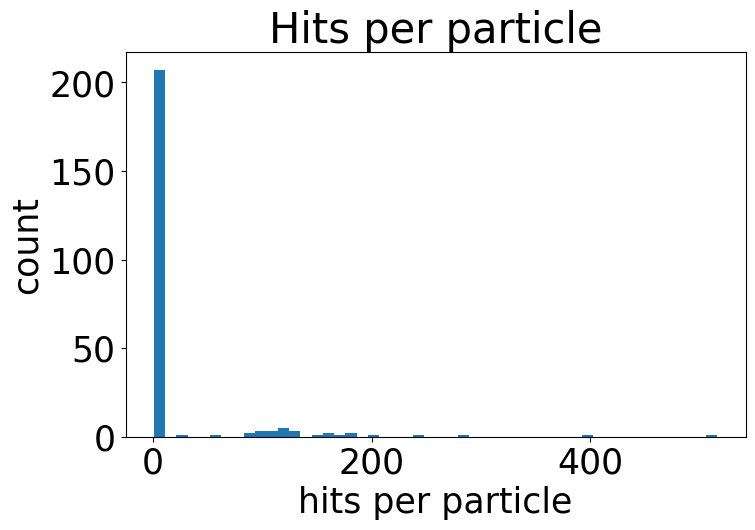


BETA DISTRIBUTION


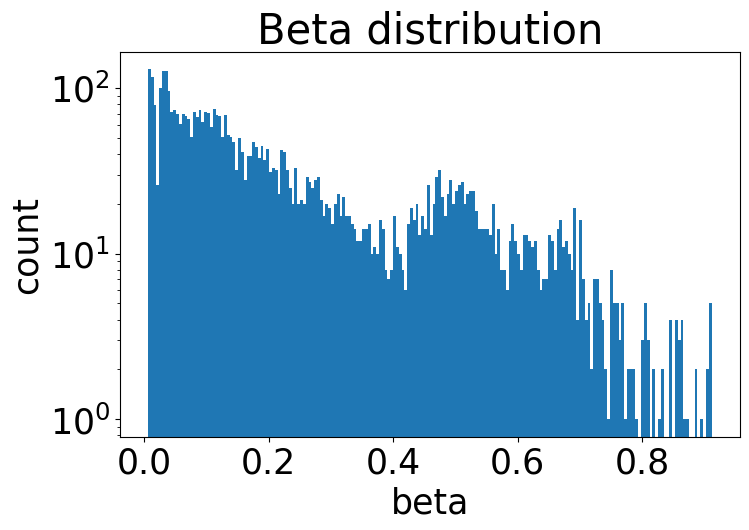


Max beta per particle:
count    236.000000
mean       0.247793
std        0.223968
min        0.007364
25%        0.082352
50%        0.148660
75%        0.379821
max        0.911942
Name: beta, dtype: float64


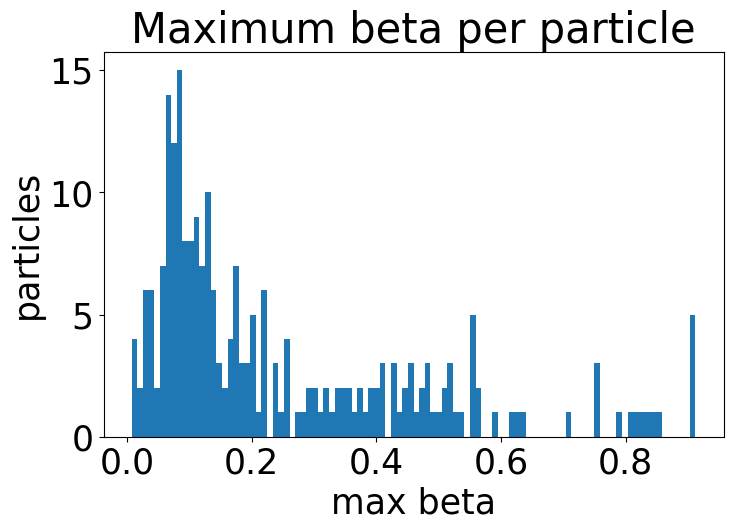


HIGH-BETA HITS (>0.9)
particle_number_original
75749.0    2
75853.0    2
28.0       1
75750.0    1
75754.0    1
dtype: int64

EMBEDDING GEOMETRY

Particles with smallest radii:
     particle  radius  n_hits
117   37233.0     0.0       1
143   37453.0     0.0       1
144   37458.0     0.0       1
145   40227.0     0.0       1
146   40250.0     0.0       1
147   40259.0     0.0       1
148   40262.0     0.0       1
149   40273.0     0.0       1
150   40303.0     0.0       1
151   40318.0     0.0       1
152   40323.0     0.0       1
153   40335.0     0.0       1
154   40356.0     0.0       1
155   40439.0     0.0       1
156   40441.0     0.0       1
157   40445.0     0.0       1
158   40446.0     0.0       1
159   40447.0     0.0       1
160   40449.0     0.0       1
161   40451.0     0.0       1

Nearest-center distance statistics:
count    236.000000
mean       0.781951
std        0.960253
min        0.026079
25%        0.171265
50%        0.465712
75%        1.083415
max        6.51

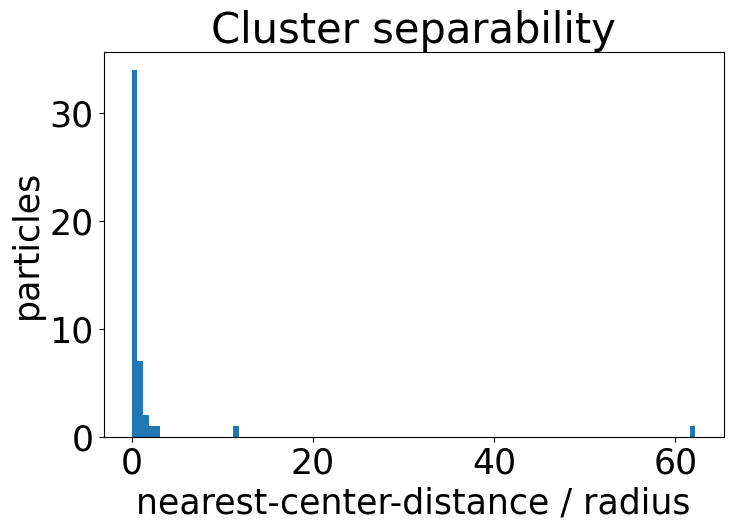


NEAREST-NEIGHBOR DISTANCES
count    4799.000000
mean        0.125255
std         0.209247
min         0.002268
25%         0.040715
50%         0.070259
75%         0.135656
max         4.889477
dtype: float64


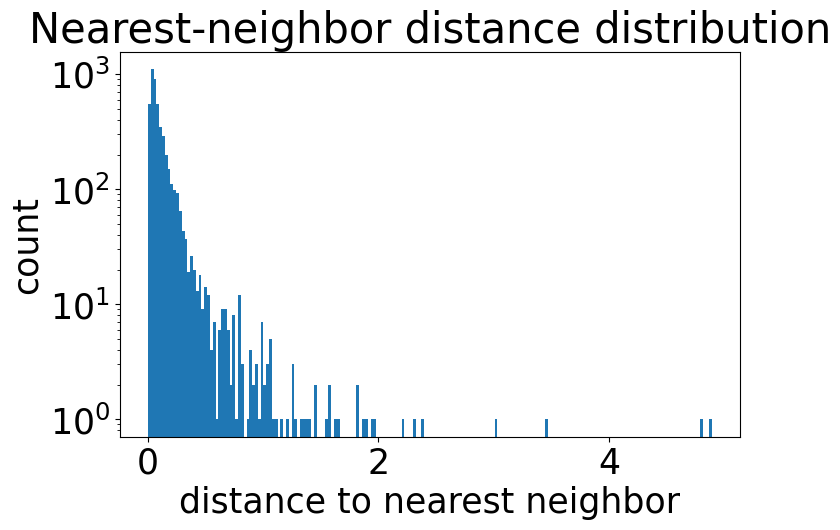


TOP 50 BETA HITS
      particle_number_original      beta
217                    75853.0  0.911942
190                       28.0  0.911787
212                    75749.0  0.910752
215                    75853.0  0.909892
208                    75750.0  0.909162
213                    75749.0  0.906047
210                    75754.0  0.905914
130                       28.0  0.895853
220                    75853.0  0.887298
132                       28.0  0.884823
214                    75749.0  0.872046
209                    75750.0  0.867307
216                    75853.0  0.866047
129                       28.0  0.865836
218                    75853.0  0.864271
211                    75749.0  0.862317
207                    75750.0  0.860015
4534                      28.0  0.859022
219                    75853.0  0.858305
222                    75951.0  0.857240
221                    75951.0  0.856623
702                       28.0  0.855134
131                       28.0  0.85424

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors

# ============================================================
# Configuration
# ============================================================
df = df_raw_hits_event.copy()

emb_cols = [f"emb{i}" for i in range(6)]
particle_col = "particle_number_original"

# ============================================================
# Dataset statistics
# ============================================================
print("=" * 80)
print("DATASET")
print("=" * 80)

print("Hits:", len(df))
print("Particles:", df[particle_col].nunique())

hits_per_particle = (
    df.groupby(particle_col)
      .size()
)

print("\nHits per particle:")
print(hits_per_particle.describe())

plt.figure(figsize=(8, 5))
plt.hist(hits_per_particle, bins=50)
plt.xlabel("hits per particle")
plt.ylabel("count")
plt.title("Hits per particle")
plt.show()

# ============================================================
# Beta distribution
# ============================================================
print("\n" + "=" * 80)
print("BETA DISTRIBUTION")
print("=" * 80)

plt.figure(figsize=(8, 5))
plt.hist(df["beta"], bins=200)
plt.yscale("log")
plt.xlabel("beta")
plt.ylabel("count")
plt.title("Beta distribution")
plt.show()

# ============================================================
# Max beta per particle
# ============================================================
max_beta_per_particle = (
    df.groupby(particle_col)["beta"]
      .max()
)

print("\nMax beta per particle:")
print(max_beta_per_particle.describe())

plt.figure(figsize=(8, 5))
plt.hist(max_beta_per_particle, bins=100)
plt.xlabel("max beta")
plt.ylabel("particles")
plt.title("Maximum beta per particle")
plt.show()

# ============================================================
# Particles contributing high-beta hits
# ============================================================
print("\n" + "=" * 80)
print("HIGH-BETA HITS (>0.9)")
print("=" * 80)

high_beta_counts = (
    df[df["beta"] > 0.9]
    .groupby(particle_col)
    .size()
    .sort_values(ascending=False)
)

print(high_beta_counts.head(30))

# ============================================================
# Embedding geometry
# ============================================================
print("\n" + "=" * 80)
print("EMBEDDING GEOMETRY")
print("=" * 80)

particle_ids = sorted(df[particle_col].unique())

centers = []
radii = []
n_hits_list = []

for pid in particle_ids:

    Xp = df.loc[
        df[particle_col] == pid,
        emb_cols
    ].values

    center = Xp.mean(axis=0)

    radius = np.mean(
        np.linalg.norm(Xp - center, axis=1)
    )

    centers.append(center)
    radii.append(radius)
    n_hits_list.append(len(Xp))

centers = np.asarray(centers)
radii = np.asarray(radii)

# ============================================================
# Particles with radius ~ 0
# ============================================================
particle_stats = pd.DataFrame({
    "particle": particle_ids,
    "radius": radii,
    "n_hits": n_hits_list,
})

print("\nParticles with smallest radii:")
print(
    particle_stats
    .sort_values("radius")
    .head(20)
)

# ============================================================
# Distance between particle centers
# ============================================================
D = pairwise_distances(centers)

np.fill_diagonal(D, np.inf)

nearest_center_distance = D.min(axis=1)

print("\nNearest-center distance statistics:")
print(pd.Series(nearest_center_distance).describe())

# ============================================================
# Separation ratio
# ============================================================
valid = radii > 1e-8

ratio = (
    nearest_center_distance[valid]
    / radii[valid]
)

print("\nSeparation ratio:")
print("valid particles:", valid.sum())
print(pd.Series(ratio).describe())

plt.figure(figsize=(8, 5))
plt.hist(ratio, bins=100)
plt.xlabel("nearest-center-distance / radius")
plt.ylabel("particles")
plt.title("Cluster separability")
plt.show()

# ============================================================
# Nearest-neighbor distances in embedding space
# ============================================================
print("\n" + "=" * 80)
print("NEAREST-NEIGHBOR DISTANCES")
print("=" * 80)

X = df[emb_cols].values

nbrs = NearestNeighbors(
    n_neighbors=2,
    n_jobs=-1
).fit(X)

distances, _ = nbrs.kneighbors(X)

nn_dist = distances[:, 1]

print(pd.Series(nn_dist).describe())

plt.figure(figsize=(8, 5))
plt.hist(nn_dist, bins=200)
plt.yscale("log")
plt.xlabel("distance to nearest neighbor")
plt.ylabel("count")
plt.title("Nearest-neighbor distance distribution")
plt.show()

# ============================================================
# Top beta hits
# ============================================================
print("\n" + "=" * 80)
print("TOP 50 BETA HITS")
print("=" * 80)

print(
    df.sort_values("beta", ascending=False)[
        [particle_col, "beta"]
    ].head(50)
)

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.decomposition import PCA

df_plot = (
    df_raw_hits_event
    .sample(min(len(df_raw_hits_event), int(1e6)), random_state=42)
    .reset_index(drop=True)
)
particle_ids_N = (
    df_plot["particle_number_original"]
    .astype("category")
    .cat.codes
    + 1
)

df_plot["particle_id"] = particle_ids_N.astype(str)
emb_cols = [f"emb{i}" for i in range(6)]
X = df_plot[emb_cols].values

pca_global = PCA(n_components=3)
X3 = pca_global.fit_transform(X)

print("Global PCA explained variance:")
print(pca_global.explained_variance_ratio_)
print(
    "Total:",
    pca_global.explained_variance_ratio_.sum()
)
directions = []

for pid, group in df_plot.groupby("particle_number_original"):

    if len(group) < 5:
        continue

    idx = group.index

    X_particle = X3[idx]

    pca_local = PCA(n_components=1)
    pca_local.fit(X_particle)

    direction = pca_local.components_[0]

    # Fix sign ambiguity
    if direction[0] < 0:
        direction = -direction

    directions.append(direction)

directions = np.asarray(directions)

print("Number of particles used:", len(directions))
mean_direction = directions.mean(axis=0)
mean_direction /= np.linalg.norm(mean_direction)

print("\nEstimated common direction:")
print(mean_direction)
tmp = np.array([0.0, 0.0, 1.0])

if abs(np.dot(tmp, mean_direction)) > 0.9:
    tmp = np.array([0.0, 1.0, 0.0])

e1 = np.cross(mean_direction, tmp)
e1 /= np.linalg.norm(e1)

e2 = np.cross(mean_direction, e1)
e2 /= np.linalg.norm(e2)
u = X3 @ e1
v = X3 @ e2
df_plane = pd.DataFrame({
    "u": u,
    "v": v,
    "particle_id": df_plot["particle_id"].values,
})
ordered_particle_ids = sorted(
    df_plane["particle_id"].unique(),
    key=lambda x: int(x)
)
fig = px.scatter(
    df_plane,
    x="u",
    y="v",
    color="particle_id",
    category_orders={
        "particle_id": ordered_particle_ids
    },
    opacity=0.7,
)

fig.update_traces(
    marker=dict(size=4)
)

fig.update_layout(
    title=(
        "Projection onto plane orthogonal "
        "to average particle direction"
    ),
    width=1200,
    height=1000,
)

fig.show()

cosines = np.abs(directions @ mean_direction)

print("Alignment with common direction")
print(pd.Series(cosines).describe())

Global PCA explained variance:
[0.6454788  0.22404042 0.09327908]
Total: 0.9627983
Number of particles used: 33

Estimated common direction:
[ 0.96802473 -0.24470405  0.05520884]


Alignment with common direction
count    33.000000
mean      0.999644
std       0.000789
min       0.996384
25%       0.999809
50%       0.999943
75%       0.999967
max       0.999983
dtype: float64


In [8]:
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# ============================================================
# Sample
# ============================================================

df_plot = (
    df_raw_hits_event
    .sample(min(len(df_raw_hits_event), int(1e6)), random_state=42)
    .reset_index(drop=True)
)

emb_cols = [f"emb{i}" for i in range(6)]
X = df_plot[emb_cols].values

# ============================================================
# Global PCA: 6D -> 3D
# ============================================================

pca_global = PCA(n_components=3)

X3 = pca_global.fit_transform(X)

print("Global PCA explained variance:")
print(pca_global.explained_variance_ratio_)
print(
    "Total:",
    pca_global.explained_variance_ratio_.sum()
)

# ============================================================
# Local PCA around each point
# ============================================================

k = 30

nn = NearestNeighbors(
    n_neighbors=k,
    algorithm="auto"
)

nn.fit(X3)

indices = nn.kneighbors(
    X3,
    return_distance=False
)

directions = []

for neigh_idx in indices:

    X_local = X3[neigh_idx]

    pca_local = PCA(n_components=1)
    pca_local.fit(X_local)

    direction = pca_local.components_[0]

    # sign convention
    if direction[0] < 0:
        direction = -direction

    directions.append(direction)

directions = np.asarray(directions)

print("Number of local directions:", len(directions))

# ============================================================
# Structure tensor
# ============================================================

T = np.zeros((3, 3))

for d in directions:
    T += np.outer(d, d)

T /= len(directions)

eigvals, eigvecs = np.linalg.eigh(T)

mean_direction = eigvecs[:, np.argmax(eigvals)]
mean_direction /= np.linalg.norm(mean_direction)

print("\nEstimated common direction:")
print(mean_direction)

print("\nTensor eigenvalues:")
print(eigvals)

# ============================================================
# Build orthogonal plane
# ============================================================

tmp = np.array([0.0, 0.0, 1.0])

if abs(np.dot(tmp, mean_direction)) > 0.9:
    tmp = np.array([0.0, 1.0, 0.0])

e1 = np.cross(mean_direction, tmp)
e1 /= np.linalg.norm(e1)

e2 = np.cross(mean_direction, e1)
e2 /= np.linalg.norm(e2)

# ============================================================
# Projection
# ============================================================

u = X3 @ e1
v = X3 @ e2

df_plane = pd.DataFrame(
    {
        "u": u,
        "v": v,
    }
)

# ============================================================
# Visualization
# ============================================================

fig = px.scatter(
    df_plane,
    x="u",
    y="v",
    opacity=0.6,
)

fig.update_traces(
    marker=dict(size=3)
)

fig.update_layout(
    title=(
        "Projection onto plane orthogonal "
        "to estimated common direction"
    ),
    width=1200,
    height=1000,
)

fig.show()

# ============================================================
# Alignment statistics
# ============================================================

cosines = np.abs(
    directions @ mean_direction
)

print("\nAlignment with common direction")
print(pd.Series(cosines).describe())

Global PCA explained variance:
[0.6454788  0.22404046 0.09327911]
Total: 0.96279836
Number of local directions: 4799

Estimated common direction:
[-0.9703541   0.23522101 -0.05553369]

Tensor eigenvalues:
[0.02759749 0.0754389  0.89696362]



Alignment with common direction
count    4799.000000
mean        0.926277
std         0.197441
min         0.000615
25%         0.982185
50%         0.998742
75%         0.999894
max         1.000000
dtype: float64


In [8]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
import pandas as pd
import plotly.express as px

# ============================================================
# Transverse coordinates from previous step
# ============================================================
# u = X3 @ e1
# v = X3 @ e2

X_transverse = np.column_stack([u, v])

# ============================================================
# Truth labels
# ============================================================
truth = (
    df_plot["particle_number_original"]
    .astype("category")
    .cat.codes
    .values
)

n_particles = len(np.unique(truth))

print("Number of particles:", n_particles)

# ============================================================
# Agglomerative clustering in transverse plane
# ============================================================
clusterer = AgglomerativeClustering(
    n_clusters=n_particles,
    linkage="ward"
)

labels = clusterer.fit_predict(X_transverse)

ari = adjusted_rand_score(
    truth,
    labels
)

print("ARI =", ari)

# ============================================================
# Store labels
# ============================================================
df_plot["cluster_label"] = labels.astype(str)

# ============================================================
# 2D projection plot
# ============================================================
df_uv = pd.DataFrame({
    "u": u,
    "v": v,
    "cluster_label": labels.astype(str),
})

fig = px.scatter(
    df_uv,
    x="u",
    y="v",
    color="cluster_label",
    opacity=0.7,
)

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    title=f"Clustering in transverse plane (ARI={ari:.4f})",
    width=1200,
    height=900,
)

fig.show()

# ============================================================
# Visualize clusters back in PCA 3D
# ============================================================
df_vis = pd.DataFrame({
    "PC1": X3[:, 0],
    "PC2": X3[:, 1],
    "PC3": X3[:, 2],
    "cluster_label": labels.astype(str),
})

fig = px.scatter_3d(
    df_vis,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster_label",
    opacity=0.7,
)

fig.update_traces(marker=dict(size=2))

fig.update_layout(
    title=f"Clusters visualized in PCA space (ARI={ari:.4f})",
    height=900,
)

fig.show()

Number of particles: 236
ARI = 0.29078893429259944


In [10]:
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# ============================================================
# Sample
# ============================================================

df_plot = (
    df_raw_hits_event
    .sample(
        min(len(df_raw_hits_event), int(1e6)),
        random_state=42,
    )
    .reset_index(drop=True)
)

# ============================================================
# Particle ids (ONLY for visualization)
# ============================================================

particle_ids_N = (
    df_plot["particle_number_original"]
    .astype("category")
    .cat.codes
    + 1
)

df_plot["particle_id"] = particle_ids_N.astype(str)

# ============================================================
# Embeddings
# ============================================================

emb_cols = [f"emb{i}" for i in range(6)]

X = df_plot[emb_cols].values

print("Input shape:", X.shape)

# ============================================================
# Global PCA
# ============================================================

pca_global = PCA(n_components=3)

X3 = pca_global.fit_transform(X)

print("\nGlobal PCA explained variance ratio:")
print(pca_global.explained_variance_ratio_)

print(
    "Total explained variance:",
    pca_global.explained_variance_ratio_.sum()
)

# ============================================================
# Local PCA around each point
# ============================================================

k = 30

nn = NearestNeighbors(
    n_neighbors=k,
    algorithm="auto"
)

nn.fit(X3)

neighbor_indices = nn.kneighbors(
    X3,
    return_distance=False
)

directions = []

for neigh_idx in neighbor_indices:

    X_local = X3[neigh_idx]

    pca_local = PCA(n_components=1)

    pca_local.fit(X_local)

    direction = pca_local.components_[0]

    # Fix sign ambiguity
    if direction[0] < 0:
        direction = -direction

    directions.append(direction)

directions = np.asarray(directions)

print(
    "\nNumber of local directions:",
    len(directions)
)

# ============================================================
# Structure tensor
# ============================================================

T = np.zeros((3, 3))

for d in directions:

    T += np.outer(d, d)

T /= len(directions)

eigvals, eigvecs = np.linalg.eigh(T)

mean_direction = eigvecs[:, np.argmax(eigvals)]

mean_direction /= np.linalg.norm(mean_direction)

print("\nEstimated common direction:")
print(mean_direction)

print("\nTensor eigenvalues:")
print(eigvals)

# ============================================================
# Alignment statistics
# ============================================================

cosines = np.abs(
    directions @ mean_direction
)

print("\nAlignment of local directions")
print(pd.Series(cosines).describe())

# ============================================================
# Build plane orthogonal to mean direction
# ============================================================

tmp = np.array([0.0, 0.0, 1.0])

if abs(np.dot(tmp, mean_direction)) > 0.9:
    tmp = np.array([0.0, 1.0, 0.0])

e1 = np.cross(mean_direction, tmp)
e1 /= np.linalg.norm(e1)

e2 = np.cross(mean_direction, e1)
e2 /= np.linalg.norm(e2)

# ============================================================
# Projection
# ============================================================

u = X3 @ e1
v = X3 @ e2

df_plane = pd.DataFrame(
    {
        "u": u,
        "v": v,
        "particle_id": df_plot["particle_id"].values,
    }
)

# ============================================================
# Plot
# ============================================================

ordered_particle_ids = sorted(
    df_plane["particle_id"].unique(),
    key=lambda x: int(x)
)

fig = px.scatter(
    df_plane,
    x="u",
    y="v",
    color="particle_id",
    category_orders={
        "particle_id": ordered_particle_ids
    },
    opacity=0.7,
)

fig.update_traces(
    marker=dict(size=4)
)

fig.update_layout(
    title=(
        "Projection onto plane orthogonal "
        "to unsupervised common direction"
    ),
    width=800,
    height=600,
)

fig.show()

# ============================================================
# Optional MC validation
# ============================================================

mc_directions = []

for pid, group in df_plot.groupby(
    "particle_number_original"
):

    if len(group) < 5:
        continue

    X_particle = X3[group.index]

    pca_particle = PCA(n_components=1)

    pca_particle.fit(X_particle)

    d = pca_particle.components_[0]

    if d[0] < 0:
        d = -d

    mc_directions.append(d)

mc_directions = np.asarray(mc_directions)

mc_cosines = np.abs(
    mc_directions @ mean_direction
)

print(
    "\nAlignment between MC track directions "
    "and unsupervised common direction"
)

print(
    pd.Series(mc_cosines).describe()
)

Input shape: (4799, 6)

Global PCA explained variance ratio:
[0.6454786  0.22404057 0.09327914]
Total explained variance: 0.9627983

Number of local directions: 4799

Estimated common direction:
[-0.97035563  0.23521442 -0.05553485]

Tensor eigenvalues:
[0.02759754 0.07543919 0.89696328]

Alignment of local directions
count    4799.000000
mean        0.926277
std         0.197441
min         0.000620
25%         0.982186
50%         0.998742
75%         0.999893
max         1.000000
dtype: float64



Alignment between MC track directions and unsupervised common direction
count    33.000000
mean      0.999596
std       0.000939
min       0.995517
25%       0.999807
50%       0.999985
75%       0.999995
max       1.000000
dtype: float64


In [ ]:
df_raw_event[df_raw_event["particle_number"]==-1]]

In [19]:
df_raw_hits_event[df_raw_hits_event["particle_number"]==-1]

,fileID,eventID,pos_x,pos_y,pos_z,hit_type,clusterID,particle_number,particle_number_original,beta,emb0,emb1,emb2,emb3,emb4,emb5
24,1002,2,-252.573547,-46.580776,307.205994,1.0,9,-1.0,46199.0,0.561082,0.130199,-0.032981,-0.031397,0.350090,-0.167784,-0.248610
25,1002,2,-252.115692,-47.342190,307.205994,1.0,10,-1.0,46199.0,0.509343,0.125385,-0.042308,-0.026673,-1.514181,0.554641,-0.122091
61,1002,2,13.725000,-0.317457,-47.801422,1.0,0,-1.0,49.0,0.476266,-0.075510,-0.033192,0.144918,-1.636705,0.530392,0.315470
66,1002,2,21.833315,-9.633591,-34.687374,1.0,0,-1.0,36451.0,0.431158,0.037131,-0.074845,0.114728,-2.924129,0.925459,0.351320
67,1002,2,28.436625,-19.044054,-21.577627,1.0,0,-1.0,36451.0,0.481174,0.039203,-0.054712,0.105237,-1.553881,0.398848,0.262626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4539,1002,2,1054.633301,359.063599,-200.657959,0.0,0,-1.0,14766.0,0.077593,-1.156187,2.204682,2.605764,-16.627234,7.286845,3.419236
4558,1002,2,1171.246338,237.590424,-246.441971,0.0,0,-1.0,14765.0,0.117926,-1.157943,2.162024,2.624312,-11.489335,5.232045,3.057348
4626,1002,2,872.760498,796.477112,-107.955978,0.0,0,-1.0,14772.0,0.137320,-1.148518,2.177175,2.655859,-11.113826,5.127476,3.142275
4665,1002,2,1618.689697,-530.237671,36.828789,0.0,0,-1.0,13028.0,0.016137,-0.970444,-2.017874,5.153166,-8.843966,-1.075127,5.433101


In [11]:
from sklearn.cluster import DBSCAN

# ============================================================
# DBSCAN on projected plane
# ============================================================

X2 = np.column_stack([u, v])

dbscan = DBSCAN(
    eps=0.15,
    min_samples=10,
)

cluster_labels = dbscan.fit_predict(X2)

df_eval = pd.DataFrame(
    {
        "cluster": cluster_labels,
        "particle": df_plot["particle_number_original"].values,
    }
)

n_clusters = len(
    set(cluster_labels) - {-1}
)

print(f"\nNumber of clusters: {n_clusters}")

# ============================================================
# Particle sizes
# ============================================================

particle_sizes = (
    df_eval.groupby("particle")
    .size()
    .to_dict()
)

# ============================================================
# Cluster evaluation
# ============================================================

cluster_results = []

matched_particles = set()

for cluster_id in sorted(df_eval["cluster"].unique()):

    if cluster_id == -1:
        continue

    cluster_hits = df_eval[
        df_eval["cluster"] == cluster_id
    ]

    cluster_size = len(cluster_hits)

    particle_counts = (
        cluster_hits["particle"]
        .value_counts()
    )

    dominant_particle = particle_counts.index[0]

    dominant_hits = particle_counts.iloc[0]

    purity = dominant_hits / cluster_size

    efficiency = (
        dominant_hits
        / particle_sizes[dominant_particle]
    )

    matched = purity > 0.75

    if matched:
        matched_particles.add(dominant_particle)

    cluster_results.append(
        {
            "cluster": cluster_id,
            "particle": dominant_particle,
            "cluster_size": cluster_size,
            "particle_hits": dominant_hits,
            "purity": purity,
            "efficiency": efficiency,
            "matched": matched,
        }
    )

cluster_results = pd.DataFrame(cluster_results)

# ============================================================
# Cluster summary
# ============================================================

print("\nCluster summary")
print(
    cluster_results[
        [
            "cluster",
            "particle",
            "cluster_size",
            "particle_hits",
            "purity",
            "efficiency",
            "matched",
        ]
    ]
)

# ============================================================
# Matched clusters
# ============================================================

matched_clusters = cluster_results[
    cluster_results["matched"]
]

print(
    "\nMatched clusters:",
    len(matched_clusters)
)

# ============================================================
# Track efficiency
# ============================================================

all_particles = set(
    df_eval["particle"].unique()
)

track_efficiency = (
    len(matched_particles)
    / len(all_particles)
)

print(
    "\nParticles reconstructed:",
    len(matched_particles),
    "/",
    len(all_particles),
)

print(
    "Track efficiency:",
    track_efficiency,
)

# ============================================================
# Purity / efficiency statistics
# ============================================================

print("\nPurity statistics")
print(
    cluster_results["purity"].describe()
)

print("\nHit efficiency statistics")
print(
    cluster_results["efficiency"].describe()
)


Number of clusters: 24

Cluster summary
    cluster  particle  cluster_size  particle_hits    purity  efficiency  \
0         0      54.0           378            366  0.968254    0.709302   
1         1      40.0           411            114  0.277372    1.000000   
2         2      34.0           118            117  0.991525    0.959016   
3         3       0.0           111            110  0.990991    0.973451   
4         4      48.0           334            183  0.547904    0.994565   
5         5   36437.0           159            159  1.000000    0.952096   
6         6   36447.0           262            241  0.919847    0.971774   
7         7      51.0           121            117  0.966942    1.000000   
8         8   36440.0           160            156  0.975000    1.000000   
9         9   36439.0           286            278  0.972028    0.982332   
10       10      45.0           150            148  0.986667    0.993289   
11       11      37.0           113            

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import os


def plot_event_display(df_dict, file_number, event_number):
    """
    Display an event with two projections (XY and ZY planes)
    for a given file_number and event_number.

    Parameters
    ----------
    df_dict : dict or pandas.DataFrame
        Dictionary (or DataFrame) containing event data with keys:
        'fileID', 'eventID', 'pos_x', 'pos_y', 'pos_z', 'hit_type', 'clusterID'.
    file_number : int
        The file ID of the event to display.
    event_number : int
        The event ID to display.
    """

    if not isinstance(df_dict, pd.DataFrame):
        df = pd.DataFrame({k: np.concatenate(v) for k, v in df_dict.items()})
    else:
        df = df_dict


    mask = (df["fileID"] == file_number) & (df["eventID"] == event_number)
    df_event = df[mask]

    if df_event.empty:
        print(f"No event found for fileID={file_number}, eventID={event_number}")
        return

  
    unique_clusters = np.unique(df_event["clusterID"])
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    ax_xy, ax_zy = axes

 
    for color, cl in zip(colors, unique_clusters):
        cluster_hits = df_event[df_event["clusterID"] == cl]

      
        ax_xy.scatter(cluster_hits["pos_x"], cluster_hits["pos_y"],
                      label=f"Cluster {cl}", s=30, alpha=0.8, color=color, edgecolor='black')
      
        ax_zy.scatter(cluster_hits["pos_z"], cluster_hits["pos_y"],
                      s=30, alpha=0.8, color=color, edgecolor='black')

 
    ax_xy.set_xlabel("x [mm]")
    ax_xy.set_ylabel("y [mm]")
    
    ax_zy.set_xlabel("z [mm]")
    ax_zy.set_ylabel("y [mm]")

    ax_xy.grid(True, linestyle=':')
    ax_zy.grid(True, linestyle=':')

    ax_xy.legend(title="Cluster ID", fontsize=10, loc="best")

    plt.tight_layout()
    plt.show()
    

def interactive_event_display(df_flat, file_number, event_number, 
                              outdir="./interactive_events", color_by="clusterID",
                              pos_cols=("pos_x","pos_y","pos_z"),
                              extra_hover=None, filename_suffix=""):
    """
    Creates an interactive 3D event display for a given event, using Plotly.
    """
    if not os.path.exists(outdir):
        os.makedirs(outdir)

  
    df_event = df_flat[(df_flat["fileID"] == file_number) & (df_flat["eventID"] == event_number)]
    if df_event.empty:
        print(f"No hits found for fileID={file_number}, eventID={event_number}")
        return


    df_event[color_by] = df_event[color_by].astype(str)

    hover_cols = extra_hover if extra_hover else []

    
    fig = px.scatter_3d(
        df_event,
        x=pos_cols[0],
        y=pos_cols[1],
        z=pos_cols[2],
        color=color_by,
        symbol="hit_type",
        size_max=6,
        opacity=0.8,
        template="plotly_dark",
        hover_data=hover_cols
    )

 
    fig.update_traces(marker=dict(line=dict(width=0)))
    
    fig.add_scatter3d(
        x=[0],
        y=[0],
        z=[0],
        mode='markers+text',
        marker=dict(size=6, color='red', symbol='x'),
        text=['(0,0,0)'],
        textposition='top center',
        name='Origin'
    )
    

    fig.update_layout(
        legend_title=color_by,
        coloraxis_showscale=False
    )

    filename = f"{outdir}/event_{file_number}_{event_number}{filename_suffix}.html"
    fig.write_html(filename)
    print(f"Interactive event display saved to {filename}")



/scratch/tmp/ipykernel_1603335/275142371.py:68: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


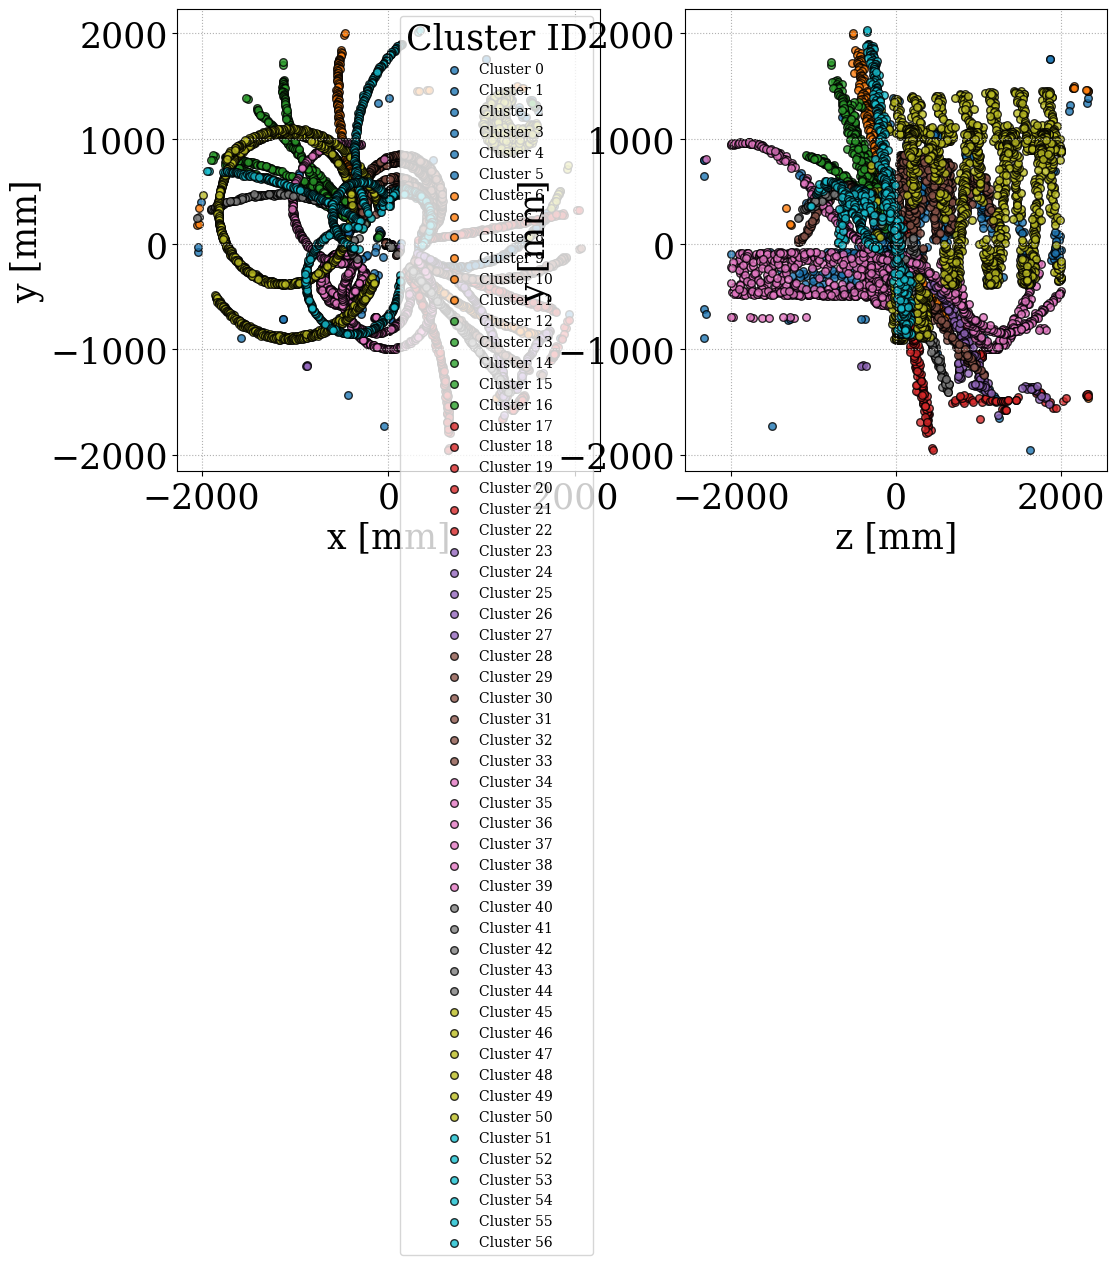

/scratch/tmp/ipykernel_1603335/275142371.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_event[color_by] = df_event[color_by].astype(str)


Interactive event display saved to ./interactive_events/event_1002_1.html


/scratch/tmp/ipykernel_1603335/275142371.py:89: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Interactive event display saved to ./interactive_events/event_1002_1_particles.html


/scratch/tmp/ipykernel_1603335/275142371.py:89: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Interactive event display saved to ./interactive_events/event_1002_1_clusters.html


In [32]:
plot_event_display(df_hits, file_number=1002, event_number=1)

interactive_event_display(
    df_hits,
    file_number=1002,
    event_number=1,
    color_by="clusterID",
    extra_hover=["particle_number", "particle_number_original", "hit_type", "pos_x", "pos_y", "pos_z"]
)

interactive_event_display(
    df_hits,
    file_number=1002,
    event_number=1,
    color_by="particle_number",
    extra_hover=["clusterID", "particle_number_original", "hit_type", "pos_x", "pos_y", "pos_z"],
    filename_suffix="_particles"
)

interactive_event_display(
    df_hits,
    file_number=1002,
    event_number=1,
    color_by="clusterID",
    pos_cols=("embedding_x", "embedding_y", "embedding_z"),
    extra_hover=["clusterID", "particle_number_original", "hit_type", "embedding_x", "embedding_y", "embedding_z","beta"],
    filename_suffix="_clusters"
)
